# Card Extraction Pipeline

Modular card extraction combining classical OpenCV methods and trained YOLO OBB model.

## Available pipelines

| Name | Steps |
|------|-------|
| `opencv_only` | `loose_quad` |
| `opencv_tighten` | `loose_quad -> tighten_quad_to_edges` |
| `yolo_only` | `YOLO detect (highest conf)` |
| `yolo_tighten` | `YOLO detect -> tighten_quad_to_edges` |
| `yolo_fallback_opencv_tighten` | `YOLO detect, fallback loose_quad, then tighten` |

Each pipeline returns a standardised result dict for side-by-side comparison.

In [1]:
# -- Imports -------------------------------------------------------------------
import glob as _glob, math, random, shutil, yaml, os
from pathlib import Path
from typing import Optional

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO

# -- Card output size ----------------------------------------------------------
CARD_W, CARD_H = 630, 880
CARD_ASPECT_TARGET = 1.397   # 63x88mm
CONF_THRESHOLD = 0.25
VERBOSE = False

# -- Dataset / output paths ----------------------------------------------------
DATASET_OUT = Path("datasets/yolo_obb_cards")

# ── Model source selector ─────────────────────────────────────────────────────
# "auto"     -> newest best.pt found across all run directories
# "train"    -> T2 model  (runs/.../train/weights/best.pt)
# "finetune" -> T5 model  (runs/.../finetune/weights/best.pt)
# "path"     -> use CUSTOM_PATH below
MODEL_SOURCE = "train_v2"  # train_v2 = real cards + complex backgrounds
CUSTOM_PATH  = ""   # used only when MODEL_SOURCE = "path"

def _find_best(run_name):
    "Search home, /opt/homebrew/runs, and DATASET_OUT for run_name weights."
    roots = [Path.home(), Path("/opt/homebrew/runs"), DATASET_OUT]
    hits  = []
    for root in roots:
        if root.exists():
            hits += list(root.rglob(f"{run_name}/weights/best.pt"))
    hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return hits[0] if hits else None

# -- Resolve BEST_WEIGHTS from MODEL_SOURCE ------------------------------------
BEST_WEIGHTS = None
if MODEL_SOURCE == "path":
    p = Path(CUSTOM_PATH)
    BEST_WEIGHTS = p if p.exists() else None
    if BEST_WEIGHTS is None:
        print(f"ERROR: CUSTOM_PATH not found: {CUSTOM_PATH}")
elif MODEL_SOURCE == "finetune":
    BEST_WEIGHTS = _find_best("finetune")
    if BEST_WEIGHTS is None:
        print("WARNING: No finetune/ weights found. Run the T5 cell in train_yolo_obb.ipynb first.")
elif MODEL_SOURCE == "auto":
    roots = [Path.home(), Path("/opt/homebrew/runs"), DATASET_OUT]
    _all  = []
    for _root in roots:
        if _root.exists():
            _all += list(_root.rglob("weights/best.pt"))
    _all.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    BEST_WEIGHTS = _all[0] if _all else None
    if BEST_WEIGHTS is None:
        print("WARNING: No trained weights found. Train a model in train_yolo_obb.ipynb first.")
else:  # treat MODEL_SOURCE as a run name (e.g. "train", "train_v2", "train3")
    BEST_WEIGHTS = _find_best(MODEL_SOURCE)
    if BEST_WEIGHTS is None:
        print(f"WARNING: No weights found for run '{MODEL_SOURCE}'. Check RUN_NAME in train_yolo_obb.ipynb.")

if BEST_WEIGHTS:
    # Label which run this came from (train / finetune / other)
    _run_label = BEST_WEIGHTS.parent.parent.name   # e.g. "train" or "finetune"
    print(f"Model source : {MODEL_SOURCE}")
    print(f"Run          : {_run_label}")
    print(f"Weights      : {BEST_WEIGHTS}")

# Reset cached model so next pipeline cell picks up the new weights
_yolo_model = None

# -- Test images ---------------------------------------------------------------
TEST_IMAGES = sorted((DATASET_OUT / "images" / "test").glob("*.jpg"))[:8]
TEST_IMAGES = sorted(Path("ungraded").glob("*.jpeg"))
print (TEST_IMAGES)
if not TEST_IMAGES:
    TEST_IMAGES = sorted((DATASET_OUT / "images" / "val").glob("*.jpg"))[:8]
if not TEST_IMAGES:
    TEST_IMAGES = (sorted(Path("to_label").glob("*.jpeg")) +
                   sorted(Path("to_label").glob("*.jpg")))
print(f"Found {len(TEST_IMAGES)} test images")

Model source : train_v2
Run          : train_v2
Weights      : /opt/homebrew/runs/obb/datasets/yolo_obb_cards_v2/train_v2/weights/best.pt
[PosixPath('ungraded/abhi_0.jpeg'), PosixPath('ungraded/ex_0_back.jpeg'), PosixPath('ungraded/ex_0_front.jpeg'), PosixPath('ungraded/ex_10_back.jpeg'), PosixPath('ungraded/ex_11_ back.jpeg'), PosixPath('ungraded/ex_11_front.jpeg'), PosixPath('ungraded/ex_12_back.jpeg'), PosixPath('ungraded/ex_12_front.jpeg'), PosixPath('ungraded/ex_13_back.jpeg'), PosixPath('ungraded/ex_13_front.jpeg'), PosixPath('ungraded/ex_14_back.jpeg'), PosixPath('ungraded/ex_14_front.jpeg'), PosixPath('ungraded/ex_15_back.jpeg'), PosixPath('ungraded/ex_15_front.jpeg'), PosixPath('ungraded/ex_16_back.jpeg'), PosixPath('ungraded/ex_16_front.jpeg'), PosixPath('ungraded/ex_1_back.jpeg'), PosixPath('ungraded/ex_1_front.jpeg'), PosixPath('ungraded/ex_3_back.jpeg'), PosixPath('ungraded/ex_3_front.jpeg'), PosixPath('ungraded/ex_4_back.jpeg'), PosixPath('ungraded/ex_4_front.jpeg'), Posi

In [2]:
def order_corners(pts: np.ndarray) -> np.ndarray:
    """Sort 4 corner points into [TL, TR, BR, BL] order."""
    pts = pts.reshape(4, 2).astype(np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1)
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = pts[np.argmin(s)]   # TL
    ordered[2] = pts[np.argmax(s)]   # BR
    ordered[1] = pts[np.argmin(d)]   # TR
    ordered[3] = pts[np.argmax(d)]   # BL
    return ordered


def perspective_warp(img: np.ndarray, corners: np.ndarray,
                     out_w: int = CARD_W, out_h: int = CARD_H) -> np.ndarray:
    """Perspective-warp the detected card region to a clean rectangle."""
    src = order_corners(corners)
    dst = np.array([[0, 0], [out_w, 0], [out_w, out_h], [0, out_h]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (out_w, out_h), flags=cv2.INTER_LANCZOS4)


def _is_card_like(corners: np.ndarray, img_h: int, img_w: int,
                  min_area_frac: float = 0.05,
                  max_area_frac: float = 0.90) -> bool:
    """
    Accept a detection only if it looks like an actual card boundary:
      - Area ≥ 5% of image     (rejects tiny in-card regions like damage box)
      - Area ≤ 90% of image    (rejects image-boundary false positive)
      - Aspect ratio 1.0–2.2   (portrait or landscape card, allows tilt)
    """
    pts  = corners.reshape(4, 2).astype(np.float32)
    area = cv2.contourArea(pts)
    img_area = img_h * img_w
    if not (min_area_frac * img_area <= area <= max_area_frac * img_area):
        return False
    rect = cv2.minAreaRect(pts)
    rw, rh = rect[1]
    if rw == 0 or rh == 0:
        return False
    aspect = max(rw, rh) / min(rw, rh)
    return 1.0 <= aspect <= 2.2


def _quad_from_mask(mask: np.ndarray) -> Optional[np.ndarray]:
    """convexHull -> minAreaRect -> boxPoints on largest contour."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt  = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(cnt)
    rect = cv2.minAreaRect(hull)
    box  = cv2.boxPoints(rect)
    return box.astype(np.float32)


def _tighten_quad_to_edges(img_bgr: np.ndarray, quad: np.ndarray,
                            inward_frac: float = 0.15, outward_frac: float = 0.04,
                            n_samples: int = 60, edge_z: float = 3.5,
                            peak_frac: float = 0.5, method: str = "offset",
                            aspect_tol: float = 0.10, cand_frac: float = 0.35,
                            max_k: int = 4, refine_window: int = 20,
                            debug: bool = False):
    """
    Snap each side of a loose quad to the card's true OUTER edge.

    Per side we build a directional, colour-aware gradient profile (Sobel on
    each LAB channel, projected onto the side normal, averaged across n_samples
    points ALONG the side) and locate the card border as the FIRST rise above
    the background floor (a low percentile of the on-image profile) — ignoring
    the stronger interior holo / text gradients further in.

    method:
      "offset"  — ONE perpendicular offset per side (fast). Assumes the loose
                  side is ~parallel to the card edge, which holds after
                  minAreaRect / Hough for in-plane ROTATION.
      "linefit" — per-along-side peak + robust line fit (cv2.fitLine, Huber), so
                  the 4 sides may be NON-PARALLEL. Handles PERSPECTIVE-skewed
                  (trapezoidal) cards. Falls back to "offset" for any side with
                  too few inlier points.
      "aspect"  — like "offset", but choose among MULTIPLE candidate edges per
                  side the combination whose quad ASPECT RATIO is closest to the
                  card's ~1.4 (CARD_ASPECT_TARGET), preferring strong edges.
                  Rejects a strong gradient spike that is background (stand /
                  shadow) instead of the real card border.

    Tuning (peak_frac is the primary knob):
      peak_frac    — fraction of (peak - floor) the first rise must clear.
                     LOWER -> catches a weaker / further-out edge; HIGHER ->
                     demands a stronger step (may skip the true edge).
      inward_frac  — hard cap on how far inward a side may move (x quad diagonal).
      edge_z       — legacy; unused (kept for call compatibility).

    method="aspect" knobs:
      aspect_tol    — allowed deviation of quad aspect from ~1.4 (fraction).
      cand_frac     — peak height (vs floor) for a side to offer a candidate.
      max_k         — candidate edges considered per side (search ~ (k+1)^4).
      refine_window — +/- px the final uniformity-snap may move each side.

    debug=True -> returns (new_corners, info) with per-side profiles, floor /
    peak / thresh / chosen-shift, the offset axis `ds`, the method, and the loose
    `ordered` corners — so visualisers plot EXACTLY what was computed here.
    """
    H, W = img_bgr.shape[:2]
    lab  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    gx = np.stack([cv2.Sobel(cv2.GaussianBlur(lab[:, :, c], (3, 3), 0),
                             cv2.CV_64F, 1, 0, ksize=3) for c in range(3)])  # (3,H,W)
    gy = np.stack([cv2.Sobel(cv2.GaussianBlur(lab[:, :, c], (3, 3), 0),
                             cv2.CV_64F, 0, 1, ksize=3) for c in range(3)])  # (3,H,W)

    ordered = order_corners(quad)
    cx, cy  = ordered[:, 0].mean(), ordered[:, 1].mean()
    diag    = np.linalg.norm(ordered[2] - ordered[0])
    d_in    = max(8, int(diag * inward_frac))
    d_out   = max(2, int(diag * outward_frac))
    ds      = np.arange(-d_out, d_in + 1)                   # ascending = outward->inward

    sides = []
    for i in range(4):
        p1, p2   = ordered[i], ordered[(i + 1) % 4]
        side_vec = p2 - p1
        side_len = np.linalg.norm(side_vec)
        s = dict(p1=p1, p2=p2, degenerate=bool(side_len < 1),
                 normal=np.zeros(2, np.float32), side_unit=np.zeros(2, np.float32),
                 base=None, dirg=None, valid=None, profile=None,
                 floor=np.nan, peak=np.nan, thresh=np.nan, shift=0.0)
        if s["degenerate"]:
            sides.append(s); continue

        side_unit = (side_vec / side_len).astype(np.float32)
        normal    = np.array([-side_unit[1], side_unit[0]], np.float32)
        mid       = (p1 + p2) / 2
        if np.dot(normal, np.array([cx, cy]) - mid) < 0:   # force INWARD
            normal = -normal
        s["side_unit"], s["normal"] = side_unit, normal

        ts   = np.linspace(0.08, 0.92, n_samples)
        base = p1[None, :] + ts[:, None] * side_vec[None, :]
        samp = base[None, :, :] + ds[:, None, None] * normal[None, None, :]
        sx = np.round(samp[..., 0]).astype(int)
        sy = np.round(samp[..., 1]).astype(int)
        valid = (sx >= 0) & (sx < W) & (sy >= 0) & (sy < H)
        sxx, syy = np.clip(sx, 0, W - 1), np.clip(sy, 0, H - 1)

        # directional gradient per channel, combined across L,a,b via L2 norm
        dir_ch = np.abs(gx[:, syy, sxx] * normal[0] + gy[:, syy, sxx] * normal[1])  # (3,D,n)
        dirg   = np.sqrt((dir_ch ** 2).sum(axis=0))                                  # (D,n)
        dirg[~valid] = 0
        profile = dirg.sum(axis=1) / np.maximum(valid.sum(axis=1), 1)
        if len(profile) >= 5:
            profile = np.convolve(profile, np.ones(5) / 5, mode="same")

        vmask = valid.sum(axis=1) > (n_samples * 0.5)
        floor = peak = thresh = np.nan
        shift = 0.0
        if vmask.sum() >= 3:
            pv    = profile[vmask]
            floor = float(np.percentile(pv, 15))            # background (table/fabric)
            peak  = float(pv.max())
            if peak > floor * 1.10 + 1e-6:                  # a real edge exists
                thresh = floor + peak_frac * (peak - floor)
                cross  = np.where((profile >= thresh) & vmask)[0]   # FIRST/outermost crossing
                shift  = float(ds[cross[0]]) if len(cross) else 0.0
        s.update(base=base, dirg=dirg, valid=valid, profile=profile,
                 floor=floor, peak=peak, thresh=thresh, shift=shift)
        sides.append(s)

    # ── Build a (point, direction) line for each side ─────────────────────────
    def _offset_line(s):
        """Single global offset: the loose side shifted perpendicular by shift."""
        mid = (s["p1"] + s["p2"]) / 2
        if s["degenerate"]:
            return mid.astype(np.float32), s["side_unit"]
        return (mid + s["shift"] * s["normal"]).astype(np.float32), s["side_unit"]

    def _linefit_line(s):
        """Per-along-side edge crossing + robust (Huber) line fit -> non-parallel ok."""
        if s["degenerate"] or np.isnan(s["thresh"]):
            return _offset_line(s)
        dirg, valid, base, normal = s["dirg"], s["valid"], s["base"], s["normal"]
        n = dirg.shape[1]
        offs = np.full(n, np.nan)
        for j in range(n):                                  # per along-side sample
            col = dirg[:, j].copy(); col[~valid[:, j]] = -1.0
            cidx = np.where(col >= s["thresh"])[0]          # first crossing of the robust thresh
            if len(cidx):
                offs[j] = ds[cidx[0]]
        good = ~np.isnan(offs)
        if good.sum() >= max(8, int(n * 0.25)):
            med = np.median(offs[good])
            mad = np.median(np.abs(offs[good] - med)) + 1e-6
            keep = good & (np.abs(offs - med) <= 3.0 * 1.4826 * mad)   # drop gross outliers
            if keep.sum() >= 8:
                pts = (base[keep] + offs[keep, None] * normal[None, :]).astype(np.float32)
                vx, vy, x0, y0 = cv2.fitLine(pts, cv2.DIST_HUBER, 0, 0.01, 0.01).ravel()
                return np.array([x0, y0], np.float32), np.array([vx, vy], np.float32)
        return _offset_line(s)                              # not enough inliers -> fall back

    def _select_aspect_shifts(target=CARD_ASPECT_TARGET, max_k=max_k,
                              cand_frac=cand_frac, tol=aspect_tol):
        """Choose, per side, the candidate edge offset whose 4-way combination
        (a) has quad aspect within `tol` of `target` (~1.4), AND (b) has a
        UNIFORM gradient along every chosen side. Uniformity = the MEDIAN
        along-side gradient at that offset (high only if MOST of the side sits on
        a real edge) — this rejects partial-length spikes (a stand, a shadow,
        interior text/art spanning only part of a side) that a MEAN cannot tell
        from a full-length border. Among feasible combos it prefers the OUTERMOST
        edges (the card border, not an inner divider). Overrides the offset-mode
        shifts only when a feasible combo is found."""
        tl, tr, br, bl = ordered
        base_w = (np.linalg.norm(tr - tl) + np.linalg.norm(br - bl)) / 2.0
        base_h = (np.linalg.norm(bl - tl) + np.linalg.norm(br - tr)) / 2.0

        def cands(s):
            base_off = float(s["shift"])
            if s["degenerate"] or s["profile"] is None or np.isnan(s["floor"]):
                return [(base_off, 1.0)]
            prof, floor, peak = s["profile"], s["floor"], s["peak"]
            dd = s["dirg"].astype(float); dd[~s["valid"]] = np.nan
            med = np.nan_to_num(np.nanmedian(dd, axis=1))      # along-side MEDIAN per offset
            rng = max(peak - floor, 1e-6)
            thr = floor + cand_frac * (peak - floor)
            peaks = [k for k in range(1, len(prof) - 1)
                     if prof[k] >= thr and prof[k] >= prof[k - 1] and prof[k] >= prof[k + 1]]
            peaks.sort(key=lambda k: -prof[k])                 # strongest mean peaks first
            offs, out = [], []
            def add(off):
                if all(abs(off - o) > 10 for o in offs):       # dedupe nearby offsets
                    di   = int(np.clip(np.searchsorted(ds, off), 0, len(ds) - 1))
                    cons = float(np.clip(med[di] / max(peak, 1e-6), 0.0, 1.0))   # uniformity
                    offs.append(off); out.append((off, cons))
            add(base_off)                                      # offset-mode pick always considered
            for k in peaks:
                add(float(ds[k]))
                if len(out) >= max_k + 1:
                    break
            return out

        cT, cR, cB, cL = cands(sides[0]), cands(sides[1]), cands(sides[2]), cands(sides[3])
        best, best_key, best_feasible = None, None, False
        for t in cT:
            for r in cR:
                for b in cB:
                    for l in cL:
                        W = base_w - l[0] - r[0]
                        H = base_h - t[0] - b[0]
                        if W <= 10 or H <= 10:
                            continue
                        aspect   = max(W, H) / min(W, H)
                        aerr     = abs(aspect - target) / target
                        feasible = aerr <= tol
                        cmin = min(t[1], r[1], b[1], l[1])     # weakest side must still be uniform
                        cavg = (t[1] + r[1] + b[1] + l[1]) / 4.0
                        total_off = t[0] + r[0] + b[0] + l[0]  # smaller => more OUTWARD
                        key = (1 if feasible else 0, round(cmin, 2),
                               -total_off, round(cavg, 3), -aerr)
                        if best_key is None or key > best_key:
                            best_key, best, best_feasible = key, (t[0], r[0], b[0], l[0]), feasible
        if best is not None and best_feasible:
            for s, sh in zip(sides, best):
                s["shift"] = float(sh)

    def _refine_uniform(window=refine_window):
        """Snap each side to the nearby offset that MAXIMISES the along-line
        gradient uniformity (median over the along-side samples). The first-rise
        pick sits on the OUTER flank of the edge (slightly loose); the median is
        maximal at the edge CENTRE = the true border, so this tightens it. A
        small `window` keeps it from hopping to a different edge."""
        for s in sides:
            if s["degenerate"] or s["dirg"] is None or s["valid"] is None:
                continue
            dd = s["dirg"].astype(float); dd[~s["valid"]] = np.nan
            med = np.nan_to_num(np.nanmedian(dd, axis=1))      # along-line uniformity per offset
            ci  = int(np.clip(np.searchsorted(ds, s["shift"]), 0, len(ds) - 1))
            lo, hi = max(0, ci - window), min(len(ds), ci + window + 1)
            seg = med[lo:hi]
            if seg.size and seg.max() > 0:
                s["shift"] = float(ds[lo + int(np.argmax(seg))])

    def _complete_with_aspect(target=CARD_ASPECT_TARGET, weak_ratio=0.5):
        """If ONE side has a weak/absent edge (low along-line uniformity at its
        chosen offset) while the other three are strong, DERIVE that side from the
        card aspect ratio instead of trusting its (invisible) gradient. Handles a
        low-contrast edge such as a dark card bottom on a dark background / stand.
        Needs 3 reliable sides; otherwise it leaves the shifts unchanged."""
        conf = []
        for s in sides:
            if s["degenerate"] or s["dirg"] is None or np.isnan(s["peak"]):
                conf.append(0.0); continue
            dd = s["dirg"].astype(float); dd[~s["valid"]] = np.nan
            med = np.nan_to_num(np.nanmedian(dd, axis=1))
            ci  = int(np.clip(np.searchsorted(ds, s["shift"]), 0, len(ds) - 1))
            conf.append(float(med[ci] / max(s["peak"], 1e-6)))
        conf = np.array(conf, dtype=float)
        weak = int(np.argmin(conf))
        others = np.delete(conf, weak)
        if others.size < 3 or np.median(others) <= 0:
            return
        if conf[weak] >= weak_ratio * np.median(others):
            return                              # no single clearly-weak side -> trust gradients
        tl, tr, br, bl = ordered
        base_w = (np.linalg.norm(tr - tl) + np.linalg.norm(br - bl)) / 2.0
        base_h = (np.linalg.norm(bl - tl) + np.linalg.norm(br - tr)) / 2.0
        sh = [s["shift"] for s in sides]        # [TOP, RIGHT, BOTTOM, LEFT]
        W  = base_w - sh[3] - sh[1]
        H  = base_h - sh[0] - sh[2]
        if W <= 1 or H <= 1:
            return
        if weak in (0, 2):                      # weak HORIZONTAL -> set height from width
            H_t    = W * target if H >= W else W / target
            strong = 2 if weak == 0 else 0      # keep the opposite (strong) horizontal side
            sides[weak]["shift"] = float((base_h - H_t) - sh[strong])
        else:                                   # weak VERTICAL -> set width from height
            W_t    = H / target if H >= W else H * target
            strong = 3 if weak == 1 else 1      # keep the opposite (strong) vertical side
            sides[weak]["shift"] = float((base_w - W_t) - sh[strong])

    if method == "aspect":
        _select_aspect_shifts()
        _refine_uniform()                  # precise snap onto the card border centre
        _complete_with_aspect()            # derive a low-contrast side from the ~1.4 ratio
        side_lines = [_offset_line(s) for s in sides]
    elif method == "linefit":
        side_lines = [_linefit_line(s) for s in sides]
    else:
        side_lines = [_offset_line(s) for s in sides]

    def line_intersect(a1, d1, a2, d2):
        cross = d1[0] * d2[1] - d1[1] * d2[0]
        if abs(cross) < 1e-8:
            return (a1 + a2) / 2
        diff = a2 - a1
        t = (diff[0] * d2[1] - diff[1] * d2[0]) / cross
        return (a1 + t * d1).astype(np.float32)

    new_corners = np.zeros((4, 2), np.float32)
    for i in range(4):
        prev = (i - 1) % 4
        new_corners[i] = line_intersect(side_lines[prev][0], side_lines[prev][1],
                                        side_lines[i][0], side_lines[i][1])
    new_corners[:, 0] = new_corners[:, 0].clip(0, W - 1)
    new_corners[:, 1] = new_corners[:, 1].clip(0, H - 1)

    if debug:
        info = dict(ordered=ordered, ds=ds, method=method,
                    names=["TOP", "RIGHT", "BOTTOM", "LEFT"],
                    sides=[dict(profile=s["profile"], floor=s["floor"], peak=s["peak"],
                                thresh=s["thresh"], shift=s["shift"]) for s in sides])
        return new_corners, info
    return new_corners


# ── Pokemon card aspect ratio (used for soft scoring only) ────────────────────
CARD_ASPECT_TARGET = 1.397   # 63×88mm -> 88/63


def _hough_quad(edge_map: np.ndarray, h: int, w: int) -> Optional[np.ndarray]:
    """
    Fallback for busy backgrounds where MORPH_CLOSE floods the frame into one
    blob (coverage > 90% -> rejected).  Finds the 4 dominant card-edge lines
    directly from the raw fused edge map and intersects them for corners —
    no closed contour required.  The loose result is refined by
    _tighten_quad_to_edges() inside the strategy.
    """
    min_side = min(h, w)
    lines = cv2.HoughLinesP(edge_map, rho=1, theta=np.pi / 180,
                            threshold=max(50, min_side // 10),
                            minLineLength=min_side * 0.20,
                            maxLineGap=min_side * 0.06)
    if lines is None or len(lines) < 4:
        return None

    h_lines, v_lines = [], []
    for x1, y1, x2, y2 in lines[:, 0]:
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
        if angle < 25 or angle > 155:      # near-horizontal
            h_lines.append((x1, y1, x2, y2))
        elif 65 < angle < 115:             # near-vertical
            v_lines.append((x1, y1, x2, y2))
    if len(h_lines) < 2 or len(v_lines) < 2:
        return None

    top_line    = min(h_lines, key=lambda l: (l[1] + l[3]) / 2)
    bottom_line = max(h_lines, key=lambda l: (l[1] + l[3]) / 2)
    left_line   = min(v_lines, key=lambda l: (l[0] + l[2]) / 2)
    right_line  = max(v_lines, key=lambda l: (l[0] + l[2]) / 2)

    def intersect(l1, l2):
        x1, y1, x2, y2 = l1; x3, y3, x4, y4 = l2
        p, d1 = np.array([x1, y1], np.float32), np.array([x2 - x1, y2 - y1], np.float32)
        q, d2 = np.array([x3, y3], np.float32), np.array([x4 - x3, y4 - y3], np.float32)
        cross = d1[0] * d2[1] - d1[1] * d2[0]
        if abs(cross) < 1e-8: return None
        t = ((q - p)[0] * d2[1] - (q - p)[1] * d2[0]) / cross
        return p + t * d1

    corners = [intersect(top_line, left_line),  intersect(top_line, right_line),
               intersect(bottom_line, right_line), intersect(bottom_line, left_line)]
    if any(c is None for c in corners):
        return None

    box = np.array(corners, dtype=np.float32)
    rect = cv2.minAreaRect(box)
    rw, rh = rect[1]
    if rw == 0 or rh == 0:
        return None
    aspect = max(rw, rh) / min(rw, rh)
    return box if 0.8 <= aspect <= 2.5 else None


def _multifilter_polygon_strategy(img_bgr: np.ndarray) -> Optional[np.ndarray]:
    """
    Strategy 1 — Multi-filter polygon detection (1vcian approach).

    Four complementary edge maps are fused:
      ① Adaptive threshold  — local contrast at any background luminance
      ② LAB L-channel Canny — lighting-invariant; ignores shadows
      ③ HSV saturation Canny— highlights colour-saturated card artwork edge
      ④ Bilateral Canny gray — smooth general-purpose detector

    Pipeline (matches the validated debug flow):
      • Adaptive MORPH_CLOSE kernel (3% of shorter dim) scales with resolution.
      • PROGRESSIVE close (3->6->10->16 iters): pick the FIRST pass that yields a
        card-like contour. Handles both clean and fragmented boundaries.
      • Hough-line FALLBACK: on busy backgrounds the close floods to a full-frame
        blob (rejected by coverage); _hough_quad() recovers a loose quad.

    Returns a LOOSE (4, 2) quad, or None. Tightening happens once, centrally, in
    loose_quad()'s consumers (opencv_find_card / visualize_tighten) — never here.
    """
    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # ── ① Adaptive threshold ─────────────────────────────────────────────────
    blur_a  = cv2.GaussianBlur(gray, (7, 7), 0)
    adapt   = cv2.adaptiveThreshold(blur_a, 255,
                                     cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
    edges_a = cv2.Canny(adapt, 30, 100)

    # ── ② LAB L-channel (lighting-invariant) ────────────────────────────────
    l_blur  = cv2.bilateralFilter(
                  cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)[:, :, 0], 9, 75, 75)
    edges_l = cv2.Canny(l_blur, 20, 60)

    # ── ③ HSV saturation (colour-discriminant) ───────────────────────────────
    _, sat_t = cv2.threshold(
                   cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)[:, :, 1],
                   30, 255, cv2.THRESH_BINARY)
    edges_s  = cv2.Canny(sat_t, 30, 100)

    # ── ④ Bilateral Canny gray (general) ────────────────────────────────────
    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
    edges_c   = cv2.bitwise_or(cv2.Canny(bilateral, 30, 80),
                                cv2.Canny(bilateral, 10, 40))

    # ── Fuse + dilate ─────────────────────────────────────────────────────────
    combined_raw = edges_a | edges_l | edges_s | edges_c
    dilated = cv2.dilate(combined_raw,
                         cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
                         iterations=2)

    # ── Adaptive kernel scaled to resolution (~3% of shorter dimension) ───────
    close_k = max(15, int(min(h, w) * 0.03))

    def _score_contours(comb):
        contours, _ = cv2.findContours(comb, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours    = sorted(contours, key=cv2.contourArea, reverse=True)[:20]
        best_box, best_score = None, -1.0
        for cnt in contours:
            if cv2.contourArea(cnt) < h * w * 0.03:
                continue
            hull = cv2.convexHull(cnt)
            rect = cv2.minAreaRect(hull)
            rw, rh = rect[1]
            if rw == 0 or rh == 0:
                continue
            box      = cv2.boxPoints(rect).astype(np.float32)
            aspect   = max(rw, rh) / min(rw, rh)
            coverage = cv2.contourArea(box) / (h * w)
            if not (0.03 <= coverage <= 0.90):
                continue
            aspect_err = abs(aspect - CARD_ASPECT_TARGET) / CARD_ASPECT_TARGET
            score = (0.60 * min(coverage / 0.70, 1.0) +
                     0.40 * max(0.0, 1.0 - aspect_err / 0.50))
            if score > best_score:
                best_score, best_box = score, box
        return best_box, best_score

    # ── Progressive MORPH_CLOSE: first pass with a card contour wins ───────────
    best_corners, best_score, found_at = None, -1.0, None
    for close_iters in (3, 6, 10, 16):
        comb = cv2.morphologyEx(
            dilated, cv2.MORPH_CLOSE,
            cv2.getStructuringElement(cv2.MORPH_RECT, (close_k, close_k)),
            iterations=close_iters)
        box, score = _score_contours(comb)
        if box is not None:
            best_corners, best_score, found_at = box, score, f"close×{close_iters}"
            break

    # ── Hough-line fallback (busy backgrounds) ────────────────────────────────
    if best_corners is None:
        best_corners = _hough_quad(combined_raw, h, w)
        if best_corners is not None:
            found_at = "hough"

    if best_corners is None:
        if VERBOSE:
            print(f"  ↳ multifilter: no quad (close_k={close_k}px, hough also failed)")
        return None

    if VERBOSE:
        cov = cv2.contourArea(best_corners) / (h * w) * 100
        print(f"  ↳ multifilter[{found_at}]: loose quad coverage={cov:.1f}%")

    return best_corners   # LOOSE quad — tightened centrally by loose_quad's consumers


def _grabcut_strategy(img_bgr: np.ndarray) -> Optional[np.ndarray]:
    """
    Strategy 2 — GrabCut foreground segmentation.
    Works for full-art / borderless cards where edge detection finds no
    clear perimeter (e.g. Charizard ex on any background).
    GrabCut rect initialised with 10% inset from each edge.
    """
    h, w   = img_bgr.shape[:2]
    pad    = 0.10
    rect   = (int(w * pad), int(h * pad),
              int(w * (1 - 2*pad)), int(h * (1 - 2*pad)))
    mask      = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    try:
        cv2.grabCut(img_bgr, mask, rect, bgd_model, fgd_model,
                    5, cv2.GC_INIT_WITH_RECT)
    except cv2.error:
        return None
    fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
                       255, 0).astype(np.uint8)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel, iterations=1)
    return _quad_from_mask(fg_mask)


def _corner_color_strategy(img_bgr: np.ndarray) -> Optional[np.ndarray]:
    """
    Strategy 3 — Border-strip background colour subtraction.
    Samples thin strips along all 4 edges as background model,
    thresholds foreground pixels, fits minAreaRect to largest contour.
    """
    h, w  = img_bgr.shape[:2]
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    strip = max(12, int(min(h, w) * 0.05))
    samples = np.vstack([
        lab[:strip,  :  ].reshape(-1, 3),
        lab[-strip:, :  ].reshape(-1, 3),
        lab[:,  :strip  ].reshape(-1, 3),
        lab[:, -strip:  ].reshape(-1, 3),
    ])
    bg_mean = np.median(samples, axis=0)
    bg_std  = np.abs(samples - bg_mean).mean(axis=0).clip(min=6, max=25)
    diff    = np.abs(lab - bg_mean)
    fg_mask = ((diff / bg_std).max(axis=2) >= 2.0).astype(np.uint8) * 255
    close_k = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    open_k  = cv2.getStructuringElement(cv2.MORPH_RECT, (9,  9))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, close_k, iterations=4)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  open_k,  iterations=1)
    fg_mask[:strip,  :] = 0; fg_mask[-strip:, :] = 0
    fg_mask[:,  :strip] = 0; fg_mask[:, -strip:] = 0
    return _quad_from_mask(fg_mask)


def opencv_find_card(img_bgr: np.ndarray) -> Optional[np.ndarray]:
    """
    Multi-strategy card boundary detector — no trained model required.

    ONE shared path (identical to what visualize_tighten plots):
      loose_quad()             -> cascade multifilter -> grabcut -> corner_colour;
                                  first card-like LOOSE quad wins
      _tighten_quad_to_edges() -> snap each side to the true outer border

    Returns (4, 2) float32 corners [TL, TR, BR, BL], or None.
    """
    h, w = img_bgr.shape[:2]
    raw, src = loose_quad(img_bgr)
    if raw is None:
        if VERBOSE: print("  All strategies failed")
        return None
    corners = _tighten_quad_to_edges(img_bgr, raw)
    if VERBOSE:
        before = cv2.contourArea(raw.astype(np.float32)) / (h * w) * 100
        after  = cv2.contourArea(corners.astype(np.float32)) / (h * w) * 100
        print(f"  {src}: accepted (area {before:.1f}% -> {after:.1f}% after tighten)")
    return corners


def detect_and_warp(image_path: str | Path, conf: float = CONF_THRESHOLD) -> dict:
    """
    Detect card boundary and perspective-warp to CARD_W × CARD_H.
    Priority: YOLO OBB (trained model) -> opencv_find_card() fallback.
    Returns dict: original, crops, corners, scores, methods, n_detected.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    img_h, img_w = img_bgr.shape[:2]
    crops, corners_list, scores, methods = [], [], [], []

    yolo_accepted = 0
    try:
        yolo_res = model.predict(img_bgr, conf=conf, verbose=False)
        yolo_obb = yolo_res[0].obb
        if yolo_obb is not None:
            for i in range(len(yolo_obb)):
                corners_px = yolo_obb.xyxyxyxy[i].cpu().numpy()
                score      = float(yolo_obb.conf[i].cpu())
                if not _is_card_like(corners_px, img_h, img_w):
                    if VERBOSE:
                        a = cv2.contourArea(corners_px.astype(np.float32))/(img_h*img_w)*100
                        print(f"  ⚠️  YOLO det #{i} rejected (area={a:.1f}%)")
                    continue
                crops.append(perspective_warp(img_bgr, corners_px))
                corners_list.append(corners_px); scores.append(score)
                methods.append("yolo");          yolo_accepted += 1
    except Exception as e:
        if VERBOSE: print(f"  ⚠️  YOLO error: {e}")

    if yolo_accepted == 0:
        if VERBOSE: print("  🔄 No valid YOLO detections -> OpenCV fallback")
        cv_corners = opencv_find_card(img_bgr)
        if cv_corners is not None:
            crops.append(perspective_warp(img_bgr, cv_corners))
            corners_list.append(cv_corners); scores.append(1.0); methods.append("opencv")

    return dict(original=img_bgr, crops=crops, corners=corners_list,
                scores=scores, methods=methods, n_detected=len(crops))


def loose_quad(img_bgr: np.ndarray):
    """
    Return the LOOSE (pre-tighten) quad from the first cascade strategy that
    yields a card-like shape, plus its source name. This is THE cascade — both
    opencv_find_card() and visualize_tighten() call it, so they stay in sync.
    """
    h, w = img_bgr.shape[:2]
    q = _multifilter_polygon_strategy(img_bgr)
    if q is not None and _is_card_like(q, h, w):
        return q, "multifilter"
    for name, fn in (("grabcut", _grabcut_strategy), ("corner_colour", _corner_color_strategy)):
        q = fn(img_bgr)
        if q is not None and _is_card_like(q, h, w):
            return q, name
    return None, None


def visualize_tighten(image_path, peak_frac: Optional[float] = None, method: str = "offset",
                      aspect_tol: Optional[float] = None, cand_frac: Optional[float] = None,
                      max_k: Optional[int] = None, refine_window: Optional[int] = None):
    """
    Single-image tighten diagnostic. Shows the loose (red) vs tightened (green)
    quad, the resulting warp, and the four per-side gradient profiles WITH the
    exact floor / threshold / chosen-offset that _tighten_quad_to_edges() used
    (debug=True) — so the plot can never drift from the live function.

    peak_frac=None uses the function's default (single source of truth); pass a
    value only to experiment.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"cannot read {image_path}"); return None
    raw, src = loose_quad(img)
    if raw is None:
        print("no strategy produced a loose quad - detection failed, not tighten."); return None

    kw = {k: v for k, v in dict(peak_frac=peak_frac, aspect_tol=aspect_tol,
                               cand_frac=cand_frac, max_k=max_k,
                               refine_window=refine_window).items() if v is not None}
    tgt, info = _tighten_quad_to_edges(img, raw, debug=True, method=method, **kw)
    overrides = ", ".join(f"{k}={v}" for k, v in kw.items()) or "all defaults"
    print(f"loose quad from: {src}   method={method}   ({overrides})")

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    vis = img.copy()
    cv2.polylines(vis, [order_corners(raw).astype(np.int32)], True, (0, 0, 255), 2)   # red  = loose
    cv2.polylines(vis, [order_corners(tgt).astype(np.int32)], True, (0, 255, 0), 3)   # green= tightened
    axes[0, 0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("red = loose   green = tightened"); axes[0, 0].axis("off")
    axes[1, 0].imshow(cv2.cvtColor(perspective_warp(img, tgt), cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("warp (tightened)"); axes[1, 0].axis("off")

    ds = info["ds"]
    for ax, name, s in zip([axes[0, 1], axes[0, 2], axes[1, 1], axes[1, 2]],
                           info["names"], info["sides"]):
        if s["profile"] is None:
            ax.set_title(f"{name}: degenerate side"); ax.axis("off"); continue
        ax.plot(ds, s["profile"])
        if not np.isnan(s["thresh"]):
            ax.axhline(s["thresh"], color="r", ls="--", label=f"thr={s['thresh']:.0f}")
        ax.axvline(s["shift"], color="g", label=f"chosen d={s['shift']:.0f}")
        ax.axvline(0, color="gray", ls=":")
        ax.set_title(f"{name}  floor={s['floor']:.0f} peak={s['peak']:.0f}")
        ax.legend(fontsize=7)
    plt.suptitle(f"{Path(image_path).name}  (tighten diagnostic)", fontsize=11)
    plt.tight_layout(); plt.show()
    return dict(raw=raw, tightened=tgt, source=src, info=info)


def find_inner_frame(img_bgr: np.ndarray, outer_quad: np.ndarray,
                     max_border_frac: float = 0.14, min_border_px: int = 3,
                     n_samples: int = 60, peak_frac: float = 0.40):
    """
    Given the OUTER card quad, find the INNER printed frame. Every Pokemon card
    has a border, so just inside the physical edge there is a second strong,
    UNIFORM, parallel edge. For each side we search INWARD from the outer edge
    for that edge; the gap is the border width.

    Returns dict:
      inner_quad   — (4,2) inner-frame corners
      widths       — per-side border width px [TOP, RIGHT, BOTTOM, LEFT] (NaN if none)
      found        — per-side bool
      perim_ratio  — perimeter(outer) / perimeter(inner)   (~1.10-1.20 for a card)
      width_cv     — coeff. of variation of the 4 widths (low = consistent border)
    """
    H, W = img_bgr.shape[:2]
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    gx = np.stack([cv2.Sobel(cv2.GaussianBlur(lab[:, :, c], (3, 3), 0),
                             cv2.CV_64F, 1, 0, ksize=3) for c in range(3)])
    gy = np.stack([cv2.Sobel(cv2.GaussianBlur(lab[:, :, c], (3, 3), 0),
                             cv2.CV_64F, 0, 1, ksize=3) for c in range(3)])

    ordered = order_corners(outer_quad)
    cx, cy  = ordered[:, 0].mean(), ordered[:, 1].mean()
    short   = min(np.linalg.norm(ordered[1] - ordered[0]),
                  np.linalg.norm(ordered[3] - ordered[0]))
    dmax    = max(min_border_px + 6, int(short * max_border_frac))
    ds      = np.arange(0, dmax + 1)

    widths, normals, found = [], [], []
    for i in range(4):
        p1, p2 = ordered[i], ordered[(i + 1) % 4]
        sv = p2 - p1; L = np.linalg.norm(sv)
        if L < 1:
            widths.append(np.nan); normals.append(np.zeros(2, np.float32)); found.append(False); continue
        su = (sv / L).astype(np.float32)
        normal = np.array([-su[1], su[0]], np.float32)
        mid = (p1 + p2) / 2
        if np.dot(normal, np.array([cx, cy]) - mid) < 0:   # inward
            normal = -normal
        normals.append(normal)

        ts = np.linspace(0.10, 0.90, n_samples)
        base = p1[None, :] + ts[:, None] * sv[None, :]
        samp = base[None, :, :] + ds[:, None, None] * normal[None, None, :]
        sx = np.round(samp[..., 0]).astype(int); sy = np.round(samp[..., 1]).astype(int)
        valid = (sx >= 0) & (sx < W) & (sy >= 0) & (sy < H)
        sxx, syy = np.clip(sx, 0, W - 1), np.clip(sy, 0, H - 1)
        dir_ch = np.abs(gx[:, syy, sxx] * normal[0] + gy[:, syy, sxx] * normal[1])
        dirg = np.sqrt((dir_ch ** 2).sum(axis=0))
        dd = dirg.astype(float); dd[~valid] = np.nan
        med = np.nan_to_num(np.nanmedian(dd, axis=1))      # along-line uniformity inward
        mx = float(med.max())
        if mx <= 1e-6:
            widths.append(np.nan); found.append(False); continue
        thr = peak_frac * mx
        # A real inner frame is a uniform peak that comes AFTER a low-gradient
        # margin (the printed border). Require the gradient to first DROP (the
        # margin) before accepting a peak — this rejects the outer-edge shoulder
        # that otherwise gives a bogus width ~= min_border_px on every side.
        seen_gap, wpx = False, None
        for k in range(min_border_px, len(med) - 1):
            if med[k] < 0.5 * thr:
                seen_gap = True
            elif seen_gap and med[k] >= thr and med[k] >= med[k - 1] and med[k] >= med[k + 1]:
                wpx = float(ds[k]); break
        if wpx is not None:
            widths.append(wpx); found.append(True)
        else:
            widths.append(np.nan); found.append(False)

    found_w = [w for w, f in zip(widths, found) if f and not np.isnan(w)]
    fill = float(np.mean(found_w)) if found_w else 0.0
    use_w = [w if (f and not np.isnan(w)) else fill for w, f in zip(widths, found)]

    def _line(i, wpx):
        mid = (ordered[i] + ordered[(i + 1) % 4]) / 2 + wpx * normals[i]
        su = ordered[(i + 1) % 4] - ordered[i]; n = np.linalg.norm(su)
        return mid.astype(np.float32), (su / n if n > 0 else su).astype(np.float32)

    def _ix(a1, d1, a2, d2):
        cr = d1[0] * d2[1] - d1[1] * d2[0]
        if abs(cr) < 1e-8: return (a1 + a2) / 2
        diff = a2 - a1; t = (diff[0] * d2[1] - diff[1] * d2[0]) / cr
        return (a1 + t * d1).astype(np.float32)

    lines = [_line(i, use_w[i]) for i in range(4)]
    inner = np.zeros((4, 2), np.float32)
    for i in range(4):
        prev = (i - 1) % 4
        inner[i] = _ix(lines[prev][0], lines[prev][1], lines[i][0], lines[i][1])

    def _perim(q):
        q = order_corners(q)
        return float(sum(np.linalg.norm(q[(j + 1) % 4] - q[j]) for j in range(4)))
    po, pi = _perim(ordered), _perim(inner)
    perim_ratio = po / pi if pi > 0 else np.nan
    width_cv = float(np.std(found_w) / np.mean(found_w)) if len(found_w) >= 2 and np.mean(found_w) > 0 else np.nan
    return dict(inner_quad=inner, widths=widths, found=found,
                perim_ratio=perim_ratio, width_cv=width_cv)


def card_border_score(img_bgr: np.ndarray, outer_quad: np.ndarray,
                      ratio_lo: float = 1.05, ratio_hi: float = 1.30,
                      cv_max: float = 0.40, aspect_tol: float = 0.12) -> dict:
    """
    Card discriminant combining BOTH cues the user identified:
      1. outer aspect ratio close to ~1.4 (CARD_ASPECT_TARGET)
      2. a printed border: outer/inner PERIMETER ratio within [ratio_lo, ratio_hi]
         and the 4 border widths reasonably consistent (width_cv <= cv_max).
    Returns find_inner_frame(...) plus aspect, aspect_err, is_card.
    """
    info = find_inner_frame(img_bgr, outer_quad)
    oc = order_corners(outer_quad)
    w = (np.linalg.norm(oc[1] - oc[0]) + np.linalg.norm(oc[2] - oc[3])) / 2.0
    h = (np.linalg.norm(oc[3] - oc[0]) + np.linalg.norm(oc[2] - oc[1])) / 2.0
    aspect = max(w, h) / min(w, h) if min(w, h) > 0 else 0.0
    aerr   = abs(aspect - CARD_ASPECT_TARGET) / CARD_ASPECT_TARGET
    pr, cv = info["perim_ratio"], info["width_cv"]
    is_card = (aerr <= aspect_tol and
               not np.isnan(pr) and ratio_lo <= pr <= ratio_hi and
               (np.isnan(cv) or cv <= cv_max))
    info.update(aspect=aspect, aspect_err=aerr, is_card=bool(is_card))
    return info


def visualize_card_border(image_path, method: str = "aspect", **tighten_kw):
    """
    Second-stage diagnostic: detect -> tighten OUTER quad -> find INNER frame.
    Draws outer (green) + inner (cyan) boxes and prints aspect, per-side border
    widths, outer/inner perimeter ratio, and the is_card verdict — use it to
    calibrate the ratio / cv thresholds before wiring this in as a hard gate.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"cannot read {image_path}"); return None
    raw, srcname = loose_quad(img)
    if raw is None:
        print("no loose quad - detection failed."); return None
    outer = _tighten_quad_to_edges(img, raw, method=method, **tighten_kw)
    info  = card_border_score(img, outer)

    vis = img.copy()
    cv2.polylines(vis, [order_corners(outer).astype(np.int32)], True, (0, 255, 0), 3)        # green outer
    cv2.polylines(vis, [order_corners(info["inner_quad"]).astype(np.int32)], True, (255, 255, 0), 2)  # cyan inner
    fig, ax = plt.subplots(1, 2, figsize=(13, 8))
    ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f"green=outer  cyan=inner frame   is_card={info['is_card']}"); ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(perspective_warp(img, outer), cv2.COLOR_BGR2RGB))
    ax[1].set_title("warp (outer)"); ax[1].axis("off")
    plt.suptitle(f"{Path(image_path).name}  (border check, method={method})", fontsize=11)
    plt.tight_layout(); plt.show()

    bw = [None if np.isnan(w) else round(w, 1) for w in info["widths"]]
    print(f"source={srcname}  method={method}")
    print(f"  aspect      = {info['aspect']:.3f}   (target {CARD_ASPECT_TARGET:.3f}, err {info['aspect_err']*100:.1f}%)")
    print(f"  border px   = {bw}   [TOP, RIGHT, BOTTOM, LEFT]")
    print(f"  width_cv    = " + ("n/a" if np.isnan(info['width_cv']) else f"{info['width_cv']:.3f}"))
    print(f"  perim ratio = " + ("n/a" if np.isnan(info['perim_ratio']) else f"{info['perim_ratio']:.3f}") + "   (outer / inner)")
    print(f"  => is_card  = {info['is_card']}")
    return info


print("Detection helpers loaded — cascade: multifilter_polygon (progressive close + Hough + "
      "self-tighten) -> grabcut -> corner_colour.")

Detection helpers loaded — cascade: multifilter_polygon (progressive close + Hough + self-tighten) -> grabcut -> corner_colour.


In [3]:
# -- Load YOLO model once ------------------------------------------------------
_yolo_model = None

def _get_yolo():
    global _yolo_model
    if _yolo_model is None:
        if BEST_WEIGHTS is None:
            raise RuntimeError("No trained weights found. Run imports cell first.")
        _yolo_model = YOLO(str(BEST_WEIGHTS))
    return _yolo_model


# -- Individual detector functions ---------------------------------------------
# All return: (quad_raw, quad_final, crop, detected, refined, method_str)
#   quad_raw   : (4,2) float32 or None  -- before tightening
#   quad_final : (4,2) float32 or None  -- after tightening (may equal quad_raw)
#   crop       : (H,W,3) uint8 or None  -- perspective-warped crop
#   detected   : bool
#   refined    : bool  -- True if tighten_quad_to_edges was applied
#   method_str : str   -- human-readable description of what fired

def detect_opencv(img_bgr, conf=CONF_THRESHOLD):
    "loose_quad only, no tightening."
    raw, src = loose_quad(img_bgr)
    if raw is None:
        return None, None, None, False, False, "opencv_only(failed)"
    crop = perspective_warp(img_bgr, raw)
    return raw, raw.copy(), crop, True, False, f"opencv_only({src})"


def detect_opencv_tighten(img_bgr, conf=CONF_THRESHOLD):
    "loose_quad then tighten_quad_to_edges."
    raw, src = loose_quad(img_bgr)
    if raw is None:
        return None, None, None, False, False, "opencv_tighten(failed)"
    tight = _tighten_quad_to_edges(img_bgr, raw)
    crop  = perspective_warp(img_bgr, tight)
    return raw, tight, crop, True, True, f"opencv_tighten({src})"


def detect_yolo(img_bgr, conf=CONF_THRESHOLD):
    "YOLO highest-confidence detection, no tightening."
    model = _get_yolo()
    h, w  = img_bgr.shape[:2]
    res   = model.predict(img_bgr, conf=conf, verbose=False, imgsz=640)
    obb   = res[0].obb if res and res[0].obb is not None else None
    if obb is None or len(obb) == 0:
        return None, None, None, False, False, "yolo_only(no_det)"
    confs = obb.conf.cpu().numpy()
    best  = int(confs.argmax())
    pts   = obb.xyxyxyxy.cpu().numpy()[best]
    if not _is_card_like(pts, h, w):
        return None, None, None, False, False, "yolo_only(rejected)"
    crop  = perspective_warp(img_bgr, pts)
    return pts, pts.copy(), crop, True, False, f"yolo_only(conf={confs[best]:.2f})"


def detect_yolo_tighten(img_bgr, conf=CONF_THRESHOLD):
    "YOLO detection then tighten_quad_to_edges."
    model = _get_yolo()
    h, w  = img_bgr.shape[:2]
    res   = model.predict(img_bgr, conf=conf, verbose=False, imgsz=640)
    obb   = res[0].obb if res and res[0].obb is not None else None
    if obb is None or len(obb) == 0:
        return None, None, None, False, False, "yolo_tighten(no_det)"
    confs = obb.conf.cpu().numpy()
    best  = int(confs.argmax())
    pts   = obb.xyxyxyxy.cpu().numpy()[best]
    if not _is_card_like(pts, h, w):
        return None, None, None, False, False, "yolo_tighten(rejected)"
    tight = _tighten_quad_to_edges(img_bgr, pts)
    crop  = perspective_warp(img_bgr, tight)
    return pts, tight, crop, True, True, f"yolo_tighten(conf={confs[best]:.2f})"


def detect_yolo_fallback_opencv_tighten(img_bgr, conf=CONF_THRESHOLD):
    "YOLO detect, fallback to OpenCV loose_quad if needed, then tighten."
    model = _get_yolo()
    h, w  = img_bgr.shape[:2]
    raw, src_label = None, ""
    try:
        res  = model.predict(img_bgr, conf=conf, verbose=False, imgsz=640)
        obb  = res[0].obb if res and res[0].obb is not None else None
        if obb is not None and len(obb) > 0:
            confs = obb.conf.cpu().numpy()
            best  = int(confs.argmax())
            pts   = obb.xyxyxyxy.cpu().numpy()[best]
            if _is_card_like(pts, h, w):
                raw, src_label = pts, f"yolo(conf={confs[best]:.2f})"
    except Exception as ex:
        src_label = f"yolo_err"
    if raw is None:
        q, fb_src = loose_quad(img_bgr)
        if q is None:
            return None, None, None, False, False, "yolo_fallback_opencv(all_failed)"
        raw, src_label = q, f"opencv_fallback({fb_src})"
    tight = _tighten_quad_to_edges(img_bgr, raw)
    crop  = perspective_warp(img_bgr, tight)
    return raw, tight, crop, True, True, f"yolo_fallback_opencv_tighten({src_label})"




def detect_loose_then_yolo_tighten(img_bgr, conf=CONF_THRESHOLD):
    """loose_quad -> warp crop -> YOLO on crop -> map corners back -> tighten.

    Rationale: YOLO sees a clean, perspective-corrected card region instead of
    the full noisy photo. Its corners (in crop space) are then projected back to
    the original image so tighten_quad_to_edges snaps to the real edge at full
    resolution. Falls back to tightening the loose quad if YOLO finds nothing.
    """
    # Step 1 -- loose quad from OpenCV cascade
    raw, src = loose_quad(img_bgr)
    if raw is None:
        return None, None, None, False, False, "loose_yolo_tighten(no_loose_quad)"

    # Step 2 -- perspective-warp the loose region to a clean crop
    ordered_src = order_corners(raw)
    dst_pts = np.array([[0, 0], [CARD_W, 0], [CARD_W, CARD_H], [0, CARD_H]],
                       dtype=np.float32)
    M_fwd = cv2.getPerspectiveTransform(ordered_src, dst_pts)
    M_inv = cv2.getPerspectiveTransform(dst_pts, ordered_src)  # crop -> original
    crop  = cv2.warpPerspective(img_bgr, M_fwd, (CARD_W, CARD_H),
                                flags=cv2.INTER_LANCZOS4)

    # Step 3 -- run YOLO on the clean crop
    model = _get_yolo()
    res   = model.predict(crop, conf=conf, verbose=False, imgsz=640)
    obb   = res[0].obb if res and res[0].obb is not None else None

    if obb is None or len(obb) == 0:
        # YOLO found nothing in the crop; tighten the raw loose quad instead
        tight    = _tighten_quad_to_edges(img_bgr, raw)
        crop_out = perspective_warp(img_bgr, tight)
        return raw, tight, crop_out, True, True, f"loose_yolo_tighten({src},no_yolo->tighten_raw)"

    # Step 4 -- pick highest-confidence detection, map corners back to original
    confs    = obb.conf.cpu().numpy()
    best     = int(confs.argmax())
    pts_crop = obb.xyxyxyxy.cpu().numpy()[best]          # (4,2) in crop space
    pts_orig = cv2.perspectiveTransform(
                   pts_crop.reshape(1, 4, 2).astype(np.float32), M_inv)[0]

    # Step 5 -- tighten on the original full-resolution image
    tight    = _tighten_quad_to_edges(img_bgr, pts_orig)
    crop_out = perspective_warp(img_bgr, tight)
    return pts_orig, tight, crop_out, True, True, (
        f"loose_yolo_tighten({src},yolo_conf={confs[best]:.2f})")



# ── Relaxed region finder + pipeline ──────────────────────────────────────────
# _is_card_like() is strict (area 5-90%, aspect 1.0-2.2) so loose_quad only
# returns confirmed card shapes.  For a "find anything, let YOLO refine" flow
# we just need a rough region — so we relax every constraint.

def _is_region_like(corners, img_h, img_w,
                    min_area_frac=0.02,   # was 0.05 -- accept small detections
                    max_area_frac=0.97,   # was 0.90 -- accept near-full-frame
                    min_aspect=0.5,       # was 1.0  -- allow wider shapes
                    max_aspect=5.0):      # was 2.2  -- allow taller shapes
    """Loose rectangular-region check, no card-shape assumption."""
    pts  = corners.reshape(4, 2).astype(np.float32)
    area = cv2.contourArea(pts)
    img_area = img_h * img_w
    if not (min_area_frac * img_area <= area <= max_area_frac * img_area):
        return False
    rect = cv2.minAreaRect(pts)
    rw, rh = rect[1]
    if rw == 0 or rh == 0:
        return False
    aspect = max(rw, rh) / min(rw, rh)
    return min_aspect <= aspect <= max_aspect


def loose_region(img_bgr):
    """Like loose_quad but with very relaxed shape constraints.

    Cascade order is the same (multifilter -> grabcut -> corner_colour) but
    the acceptance test uses _is_region_like instead of _is_card_like, so
    non-card-like rectangles (too square, too thin, near-full-frame) are kept.
    Use as a first-pass region detector before running YOLO for precise corners.
    Returns (quad, source_name) or (None, None).
    """
    h, w = img_bgr.shape[:2]
    for name, fn in (
        ("multifilter",   _multifilter_polygon_strategy),
        ("grabcut",       _grabcut_strategy),
        ("corner_colour", _corner_color_strategy),
    ):
        q = fn(img_bgr)
        if q is not None and _is_region_like(q, h, w):
            return q, name
    return None, None


def detect_region_then_yolo_tighten(img_bgr, conf=CONF_THRESHOLD):
    """loose_region (relaxed) -> warp crop -> YOLO on crop -> map back -> tighten.

    Same mechanics as loose_then_yolo_tighten but the initial region finder
    uses _is_region_like (looser area + aspect thresholds) so it succeeds even
    when the card is very small, very large in frame, or at an unusual tilt that
    confuses _is_card_like.  YOLO then produces precise corners inside that crop,
    and tighten_quad_to_edges snaps to the true card edge at full resolution.
    """
    raw, src = loose_region(img_bgr)
    if raw is None:
        return None, None, None, False, False, "region_yolo_tighten(no_region)"

    # Warp the loose region to a clean crop
    ordered_src = order_corners(raw)
    dst_pts = np.array([[0, 0], [CARD_W, 0], [CARD_W, CARD_H], [0, CARD_H]],
                       dtype=np.float32)
    M_fwd = cv2.getPerspectiveTransform(ordered_src, dst_pts)
    M_inv = cv2.getPerspectiveTransform(dst_pts, ordered_src)
    crop  = cv2.warpPerspective(img_bgr, M_fwd, (CARD_W, CARD_H),
                                flags=cv2.INTER_LANCZOS4)

    # Run YOLO on the clean crop
    model = _get_yolo()
    res   = model.predict(crop, conf=conf, verbose=False, imgsz=640)
    obb   = res[0].obb if res and res[0].obb is not None else None

    if obb is None or len(obb) == 0:
        # YOLO found nothing -- tighten directly on the raw region
        tight    = _tighten_quad_to_edges(img_bgr, raw)
        crop_out = perspective_warp(img_bgr, tight)
        return raw, tight, crop_out, True, True, f"region_yolo_tighten({src},no_yolo->tighten_raw)"

    # Map highest-confidence YOLO corners from crop space back to original
    confs    = obb.conf.cpu().numpy()
    best     = int(confs.argmax())
    pts_crop = obb.xyxyxyxy.cpu().numpy()[best]
    pts_orig = cv2.perspectiveTransform(
                   pts_crop.reshape(1, 4, 2).astype(np.float32), M_inv)[0]

    tight    = _tighten_quad_to_edges(img_bgr, pts_orig)
    crop_out = perspective_warp(img_bgr, tight)
    return pts_orig, tight, crop_out, True, True, (
        f"region_yolo_tighten({src},yolo_conf={confs[best]:.2f})")


# -- SAHI detector + lazy model loader ----------------------------------------
# SAHI tiles the image into overlapping 640x640 patches, runs YOLO on each,
# then merges detections via NMS. Best for small/far cards where standard YOLO
# misses but there is enough pixel detail in a tile.
#
# Limitations:
#   - SAHI does not support MPS; it runs on CPU automatically.
#   - SAHI returns axis-aligned bboxes (not OBB). tighten_quad_to_edges then
#     snaps to the true rotated card edge, so the final crop is still precise.
#   - Slower than direct YOLO (~2-5x on CPU for a 640px image).
#
# Requires: pip install sahi

# Pixels to pad every SAHI bbox outward before passing to the next stage.
# A small pad ensures the card edge isn't clipped when tighten_quad_to_edges
# searches outward from the detection boundary.
SAHI_PADDING = 100

_sahi_model = None

def _get_sahi(conf=CONF_THRESHOLD):
    global _sahi_model
    if _sahi_model is None:
        try:
            from sahi import AutoDetectionModel
        except ImportError:
            raise ImportError('SAHI not installed. Run: pip install sahi')
        if BEST_WEIGHTS is None:
            raise RuntimeError('No trained weights. Run imports cell first.')
        _sahi_model = AutoDetectionModel.from_pretrained(
            model_type           = 'ultralytics',
            model_path           = str(BEST_WEIGHTS),
            confidence_threshold = conf,
            device               = 'cpu',   # MPS not supported by SAHI
        )
    return _sahi_model


def detect_sahi(img_bgr, conf=CONF_THRESHOLD):
    """SAHI sliced inference -> best bbox -> tighten_quad_to_edges.

    Slices the image into overlapping 640x640 tiles, runs YOLO on each,
    merges detections via NMS, then tightens the best bbox to the true
    card edge. Helps find cards that are small in frame or missed by
    standard single-pass YOLO.

    Falls back gracefully if SAHI is not installed (returns not-detected).
    """
    try:
        from sahi.predict import get_sliced_prediction
        import PIL.Image as PILImage
    except ImportError:
        return None, None, None, False, False, 'sahi_tighten(pip install sahi)'

    h, w = img_bgr.shape[:2]
    try:
        model   = _get_sahi(conf)
        img_pil = PILImage.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        result  = get_sliced_prediction(
            img_pil, model,
            slice_height         = 640,
            slice_width          = 640,
            overlap_height_ratio = 0.25,
            overlap_width_ratio  = 0.25,
            verbose              = 0,
        )
    except Exception as ex:
        return None, None, None, False, False, f'sahi_tighten(error:{ex})'

    preds = result.object_prediction_list
    if not preds:
        return None, None, None, False, False, 'sahi_tighten(no_det)'

    # Apply padding via supervision then pick highest-confidence detection
    try:
        import supervision as sv
        sv_dets = sv.Detections.from_sahi(result)
        sv_dets = sv_dets.with_nms()
        padded  = sv_dets.with_padding(padding=SAHI_PADDING)
        # xyxy shape: (N,4) -> pick highest confidence row
        best_i  = int(sv_dets.confidence.argmax())
        x1, y1, x2, y2 = padded.xyxy[best_i]
        conf_val = float(sv_dets.confidence[best_i])
    except Exception:
        # supervision not installed or failed — fall back to raw SAHI bbox
        best     = max(preds, key=lambda p: p.score.value)
        b        = best.bbox
        x1, y1, x2, y2 = b.minx, b.miny, b.maxx, b.maxy
        conf_val = best.score.value

    # Clamp to image bounds after padding
    x1, y1 = max(0.0, float(x1)), max(0.0, float(y1))
    x2, y2 = min(float(w), float(x2)), min(float(h), float(y2))

    # Axis-aligned bbox -> 4 corners [TL, TR, BR, BL]
    pts = np.array([
        [x1, y1],
        [x2, y1],
        [x2, y2],
        [x1, y2],
    ], dtype=np.float32)

    if not _is_card_like(pts, h, w):
        return None, None, None, False, False, (
            f'sahi(rejected,conf={conf_val:.2f})')

    # Warp directly from padded bbox — no tighten (tighten cuts into card edge)
    crop_out = perspective_warp(img_bgr, pts)
    return pts, pts, crop_out, True, False, f'sahi(conf={conf_val:.2f},pad={SAHI_PADDING}px)'



def detect_sahi_then_yolo(img_bgr, conf=CONF_THRESHOLD):
    "SAHI sliced region -> warp crop -> YOLO on crop -> map back -> tighten."
    try:
        from sahi.predict import get_sliced_prediction
        import PIL.Image as PILImage
    except ImportError:
        return None, None, None, False, False, "sahi_yolo_tighten(pip install sahi)"

    h, w = img_bgr.shape[:2]

    # Step 1 -- SAHI sliced inference to locate the card region
    try:
        sahi_m  = _get_sahi(conf)
        img_pil = PILImage.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        result  = get_sliced_prediction(
            img_pil, sahi_m,
            slice_height         = 640,
            slice_width          = 640,
            overlap_height_ratio = 0.25,
            overlap_width_ratio  = 0.25,
            verbose              = 0,
        )
    except Exception as ex:
        return None, None, None, False, False, f"sahi_yolo_tighten(sahi_error)"

    preds = result.object_prediction_list
    if not preds:
        return None, None, None, False, False, "sahi_yolo_tighten(no_sahi_det)"

    # Apply padding via supervision then pick highest-confidence detection
    try:
        import supervision as sv
        sv_dets   = sv.Detections.from_sahi(result)
        sv_dets   = sv_dets.with_nms()
        padded    = sv_dets.with_padding(padding=SAHI_PADDING)
        best_i    = int(sv_dets.confidence.argmax())
        x1, y1, x2, y2 = padded.xyxy[best_i]
        sahi_conf = float(sv_dets.confidence[best_i])
    except Exception:
        # supervision not installed — fall back to raw SAHI bbox
        best      = max(preds, key=lambda p: p.score.value)
        b         = best.bbox
        x1, y1, x2, y2 = b.minx, b.miny, b.maxx, b.maxy
        sahi_conf = best.score.value

    # Clamp to image bounds after padding
    x1, y1 = max(0.0, float(x1)), max(0.0, float(y1))
    x2, y2 = min(float(w), float(x2)), min(float(h), float(y2))

    # Axis-aligned SAHI bbox -> 4 corners
    raw = np.array([
        [x1, y1],
        [x2, y1],
        [x2, y2],
        [x1, y2],
    ], dtype=np.float32)

    if not _is_card_like(raw, h, w):
        return None, None, None, False, False, f"sahi_yolo_tighten(sahi_rejected)"

    # Step 2 -- warp the SAHI region to a clean crop
    ordered_src = order_corners(raw)
    dst_pts = np.array([[0, 0], [CARD_W, 0], [CARD_W, CARD_H], [0, CARD_H]],
                       dtype=np.float32)
    M_fwd = cv2.getPerspectiveTransform(ordered_src, dst_pts)
    M_inv = cv2.getPerspectiveTransform(dst_pts, ordered_src)
    crop  = cv2.warpPerspective(img_bgr, M_fwd, (CARD_W, CARD_H),
                                flags=cv2.INTER_LANCZOS4)

    # Step 3 -- YOLO on the clean crop
    yolo_m = _get_yolo()
    res    = yolo_m.predict(crop, conf=conf, verbose=False, imgsz=640)
    obb    = res[0].obb if res and res[0].obb is not None else None

    if obb is None or len(obb) == 0:
        # YOLO found nothing in crop -- warp from raw SAHI bbox directly
        crop_out = perspective_warp(img_bgr, raw)
        return raw, raw, crop_out, True, False, (
            f"sahi_yolo(sahi={sahi_conf:.2f},no_yolo->raw_warp)")

    # Step 4 -- map YOLO corners from crop space back to original image
    confs    = obb.conf.cpu().numpy()
    best_i   = int(confs.argmax())
    pts_crop = obb.xyxyxyxy.cpu().numpy()[best_i]
    pts_orig = cv2.perspectiveTransform(
                   pts_crop.reshape(1, 4, 2).astype(np.float32), M_inv)[0]

    # Step 5 -- warp directly from YOLO corners (no tighten)
    crop_out = perspective_warp(img_bgr, pts_orig)
    return pts_orig, pts_orig, crop_out, True, False, (
        f"sahi_yolo(sahi={sahi_conf:.2f},yolo={confs[best_i]:.2f})")



# -- Rotated IoU helper (used by sliding window NMS) --------------------------
def _rotated_iou(pts_a: np.ndarray, pts_b: np.ndarray) -> float:
    """Polygon IoU between two convex quads (shape (4,2) float32).

    Uses cv2.intersectConvexConvex which handles arbitrary convex polygons,
    so it works correctly for rotated / tilted cards.
    """
    a = pts_a.reshape(4, 1, 2).astype(np.float32)
    b = pts_b.reshape(4, 1, 2).astype(np.float32)
    _ret, inter = cv2.intersectConvexConvex(a, b)
    if _ret == 0 or inter is None or len(inter) == 0:
        return 0.0
    inter_area = cv2.contourArea(inter)
    area_a     = cv2.contourArea(a)
    area_b     = cv2.contourArea(b)
    union_area  = area_a + area_b - inter_area
    return float(inter_area / union_area) if union_area > 0 else 0.0


# -- Sliding window detector ---------------------------------------------------
SW_TILE    = 640     # tile size (matches YOLO training imgsz)
SW_OVERLAP = 0.25    # overlap fraction between adjacent tiles
SW_NMS_IOU = 0.30    # suppress detections with rotated IoU above this


def detect_sliding_window(img_bgr, conf=CONF_THRESHOLD):
    """Manual sliding window over the image, YOLO OBB on every tile, rotated NMS.

    Unlike SAHI (which wraps YOLO internally and collapses to axis-aligned
    bboxes), this approach:
      1. Tiles the image with overlapping windows.
      2. Runs YOLO OBB on each tile and maps OBB corners back to original space.
      3. Merges via greedy rotated-IoU NMS so truly rotated cards are handled.

    Tile layout ensures the right/bottom edge is always covered by a final tile
    even when image dimensions are not multiples of SW_TILE.
    """
    h, w = img_bgr.shape[:2]
    model = _get_yolo()
    step  = max(1, int(SW_TILE * (1 - SW_OVERLAP)))

    # Build tile origins — always include edge-aligned tiles so nothing is missed
    def _origins(size, tile, step):
        origs = list(range(0, size - tile, step)) if size > tile else []
        origs.append(max(0, size - tile))          # final edge tile
        return sorted(set(origs))

    all_pts, all_confs = [], []

    for y0 in _origins(h, SW_TILE, step):
        for x0 in _origins(w, SW_TILE, step):
            patch = img_bgr[y0:y0+SW_TILE, x0:x0+SW_TILE]
            res   = model.predict(patch, conf=conf, verbose=False, imgsz=SW_TILE)
            obb   = res[0].obb if res and res[0].obb is not None else None
            if obb is None or len(obb) == 0:
                continue
            confs_p = obb.conf.cpu().numpy()
            pts_all = obb.xyxyxyxy.cpu().numpy()   # (N, 4, 2) in patch space
            for i in range(len(confs_p)):
                pts = pts_all[i].copy().astype(np.float32)
                pts[:, 0] += x0    # map X back to original image
                pts[:, 1] += y0    # map Y back to original image
                all_pts.append(pts)
                all_confs.append(float(confs_p[i]))

    if not all_pts:
        n_tiles = len(_origins(h, SW_TILE, step)) * len(_origins(w, SW_TILE, step))
        return None, None, None, False, False, f"sliding_window(no_det,{n_tiles}_tiles)"

    # Greedy rotated NMS: process highest-confidence first
    order = sorted(range(len(all_confs)), key=lambda i: -all_confs[i])
    keep  = []
    for i in order:
        if all(_rotated_iou(all_pts[i], all_pts[j]) < SW_NMS_IOU for j in keep):
            keep.append(i)

    # Best surviving detection
    best      = keep[0]
    pts_best  = all_pts[best]
    conf_best = all_confs[best]
    n_raw     = len(all_pts)
    n_kept    = len(keep)

    if not _is_card_like(pts_best, h, w):
        return None, None, None, False, False, (
            f"sliding_window(rejected,conf={conf_best:.2f})")

    crop = perspective_warp(img_bgr, pts_best)
    return pts_best, pts_best, crop, True, False, (
        f"sliding_window(conf={conf_best:.2f},{n_raw}_raw->{n_kept}_kept)")

# -- Pipeline registry ---------------------------------------------------------
PIPELINES = [
    {"name": "opencv_only",                  "fn": detect_opencv,                       "color": (0.5, 0.5, 0.8)},
    {"name": "opencv_tighten",               "fn": detect_opencv_tighten,               "color": (0.2, 0.5, 1.0)},
    {"name": "yolo_only",                    "fn": detect_yolo,                         "color": (1.0, 0.6, 0.1)},
    {"name": "yolo_tighten",                 "fn": detect_yolo_tighten,                 "color": (0.9, 0.3, 0.1)},
    {"name": "yolo_fallback_opencv_tighten", "fn": detect_yolo_fallback_opencv_tighten, "color": (0.2, 0.8, 0.4)},
    {"name": "loose_then_yolo_tighten",      "fn": detect_loose_then_yolo_tighten,      "color": (0.8, 0.2, 0.9)},
    {"name": "region_then_yolo_tighten",     "fn": detect_region_then_yolo_tighten,     "color": (0.3, 0.9, 0.6)},
    {"name": "sliding_window",           "fn": detect_sliding_window,              "color": (0.2, 0.85, 0.9)},
    {"name": "sahi",                         "fn": detect_sahi,                 "color": (0.9, 0.7, 0.1)},
    {"name": "sahi_then_yolo",               "fn": detect_sahi_then_yolo,       "color": (0.5, 0.95, 0.2)},
]


def run_pipeline(img_bgr, pipeline, conf=CONF_THRESHOLD):
    "Run one pipeline and return a standardised result dict."
    quad_raw, quad_final, crop, detected, refined, method = pipeline["fn"](img_bgr, conf)
    return {
        "pipeline":   pipeline["name"],
        "method":     method,
        "quad_raw":   quad_raw,
        "quad_final": quad_final,
        "crop":       crop,
        "detected":   detected,
        "refined":    refined,
    }

print("Pipelines ready:", [p["name"] for p in PIPELINES])

Pipelines ready: ['opencv_only', 'opencv_tighten', 'yolo_only', 'yolo_tighten', 'yolo_fallback_opencv_tighten', 'loose_then_yolo_tighten', 'region_then_yolo_tighten', 'sliding_window', 'sahi', 'sahi_then_yolo']


Image: crops_pipeline/test/s-l500.png  (383x500)


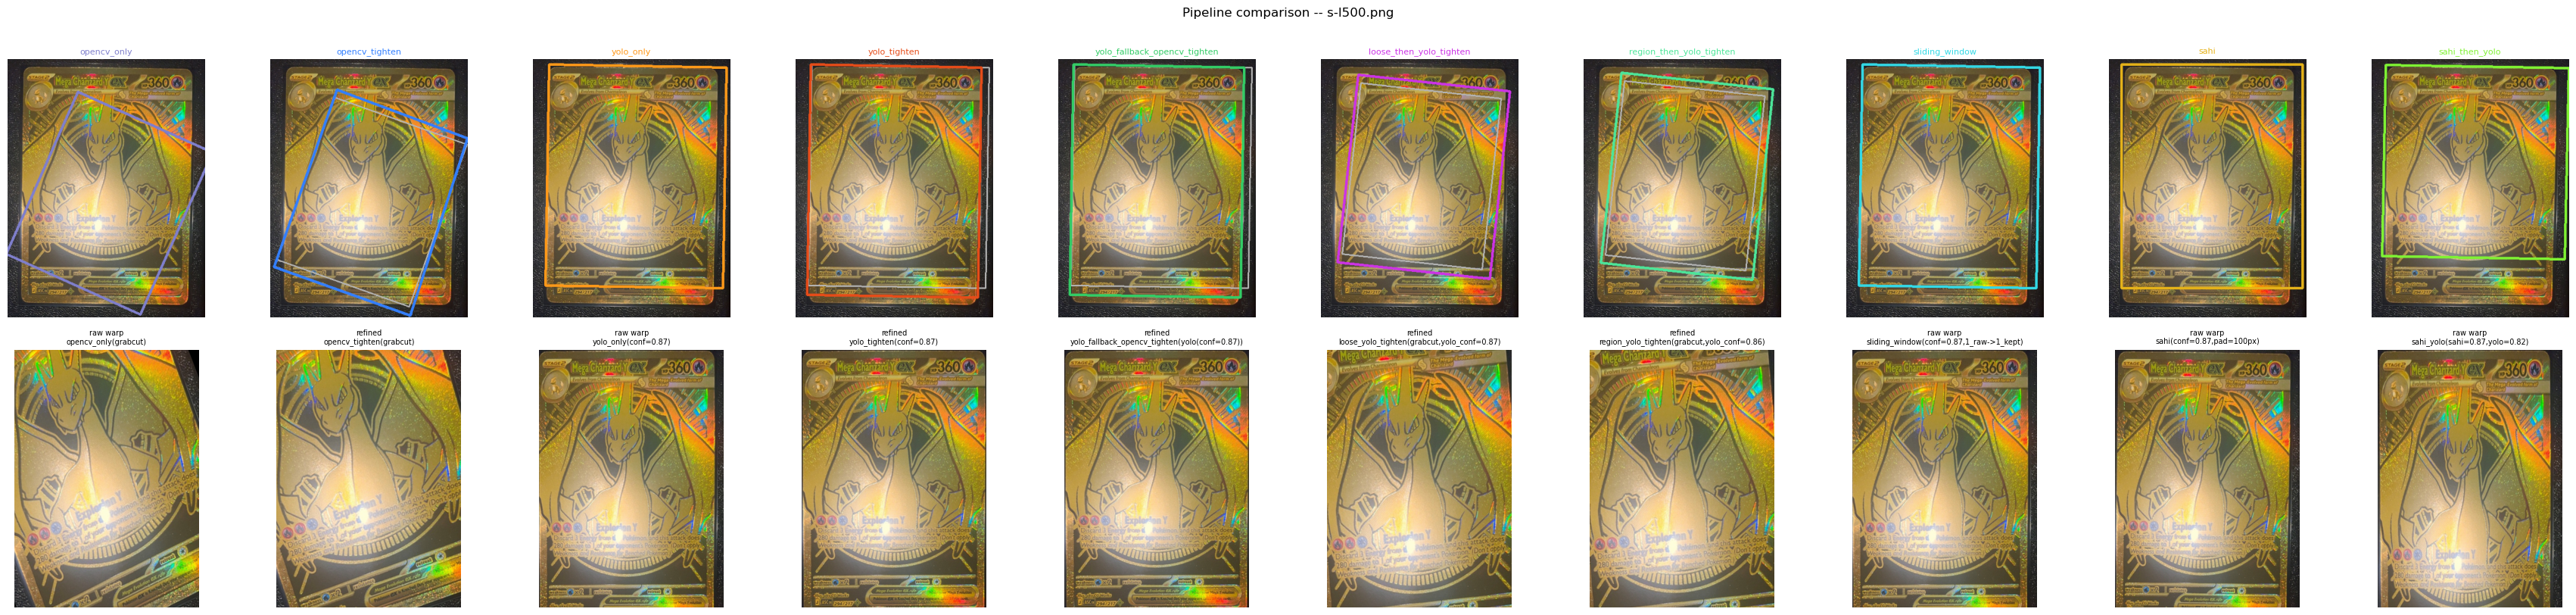

In [4]:
# -- Single-image comparison ---------------------------------------------------
# Change IMAGE_PATH to any image you want to test
IMAGE_PATH = TEST_IMAGES[0] if TEST_IMAGES else "to_label/abhi_0.jpeg"

IMAGE_PATH = "crops_pipeline/test/card1_front.png"
IMAGE_PATH  = "crops_pipeline/test/s-l500.png"

img = cv2.imread(str(IMAGE_PATH))
assert img is not None, f"Cannot read image: {IMAGE_PATH}"
print(f"Image: {IMAGE_PATH}  ({img.shape[1]}x{img.shape[0]})")

results = [run_pipeline(img, p) for p in PIPELINES]

# -- Visualise -----------------------------------------------------------------
n = len(PIPELINES)
fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 8))

for col, (p, r) in enumerate(zip(PIPELINES, results)):
    color_bgr = tuple(int(c * 255) for c in reversed(p["color"]))

    # Top row: original with quads overlaid
    vis = img.copy()
    if r["quad_raw"] is not None:
        cv2.polylines(vis, [order_corners(r["quad_raw"]).astype(np.int32)],
                      True, (180, 180, 180), 2)        # grey = raw/loose
    if r["quad_final"] is not None:
        cv2.polylines(vis, [order_corners(r["quad_final"]).astype(np.int32)],
                      True, color_bgr, 3)              # coloured = final
    axes[0, col].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(p["name"], fontsize=8, color=p["color"])
    axes[0, col].axis("off")

    # Bottom row: warped crop or failure placeholder
    if r["crop"] is not None:
        axes[1, col].imshow(cv2.cvtColor(r["crop"], cv2.COLOR_BGR2RGB))
        status = "refined" if r["refined"] else "raw warp"
    else:
        axes[1, col].set_facecolor("#111")
        axes[1, col].text(0.5, 0.5, "not detected",
                          ha="center", va="center", color="white",
                          transform=axes[1, col].transAxes, fontsize=9)
        status = "FAILED"
    axes[1, col].set_title(f"{status}\n{r['method']}", fontsize=7)
    axes[1, col].axis("off")

plt.suptitle(f"Pipeline comparison -- {Path(str(IMAGE_PATH)).name}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [5]:
# -- Batch run: all test images x all pipelines --------------------------------
BATCH_IMAGES = TEST_IMAGES[0:1]   # or assign: list(Path("my_folder").glob("*.jpg"))

rows = []
for img_path in BATCH_IMAGES:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    row = {"image": Path(img_path).name}
    for p in PIPELINES:
        r = run_pipeline(img, p)
        row[p["name"]] = ("OK(r)" if (r["detected"] and r["refined"])
                          else "OK" if r["detected"] else "FAIL")
    rows.append(row)

if rows:
    cols = ["image"] + [p["name"] for p in PIPELINES]
    col_w = {c: max(len(c), max(len(str(r[c])) for r in rows)) for c in cols}
    header = "  ".join(c.ljust(col_w[c]) for c in cols)
    print(header)
    print("-" * len(header))
    for r in rows:
        print("  ".join(str(r[c]).ljust(col_w[c]) for c in cols))
    print()
    for p in PIPELINES:
        n_ok = sum(1 for r in rows if r[p["name"]] != "FAIL")
        print(f"  {p['name']:45s}: {n_ok}/{len(rows)} detected")
else:
    print("No images to batch over. Set BATCH_IMAGES to a list of paths.")


image        opencv_only  opencv_tighten  yolo_only  yolo_tighten  yolo_fallback_opencv_tighten  loose_then_yolo_tighten  region_then_yolo_tighten  sliding_window  sahi  sahi_then_yolo
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
abhi_0.jpeg  OK           OK(r)           OK         OK(r)         OK(r)                         OK(r)                    OK(r)                     OK              OK    OK            

  opencv_only                                  : 1/1 detected
  opencv_tighten                               : 1/1 detected
  yolo_only                                    : 1/1 detected
  yolo_tighten                                 : 1/1 detected
  yolo_fallback_opencv_tighten                 : 1/1 detected
  loose_then_yolo_tighten                      : 1/1 detected
  region_then_yolo_tighten                     : 1/1 detected
  sliding_

In [6]:
# -- Save warped crops from a chosen pipeline ----------------------------------
CHOSEN_PIPELINE = "sahi_then_yolo"   # change to any pipeline name
SAVE_DIR        = Path("crops_pipeline") / CHOSEN_PIPELINE
SAVE_DIR.mkdir(parents=True, exist_ok=True)

pipeline = next(p for p in PIPELINES if p["name"] == CHOSEN_PIPELINE)
saved, failed = 0, 0

# For SAHI pipelines: adjust SAHI_PADDING in cell 3 before running
_is_sahi = "sahi" in CHOSEN_PIPELINE
if _is_sahi:
    print(f"SAHI pipeline — padding: {SAHI_PADDING}px per side")

for img_path in BATCH_IMAGES:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    r = run_pipeline(img, pipeline)
    if r["crop"] is not None:
        out_path = SAVE_DIR / (Path(img_path).stem + "_crop.jpg")
        cv2.imwrite(str(out_path), r["crop"])
        saved += 1
    else:
        failed += 1

print(f"Pipeline : {CHOSEN_PIPELINE}")
print(f"Saved    : {saved} crops  ->  {SAVE_DIR}")
if failed:
    print(f"Failed   : {failed} image(s) — no card detected")


SAHI pipeline — padding: 100px per side
Pipeline : sahi_then_yolo
Saved    : 1 crops  ->  crops_pipeline/sahi_then_yolo


In [11]:
# ── SAHI: Sliced Inference for small/far cards ────────────────────────────────────────────
# SAHI slices the image into overlapping tiles, runs YOLO on each, then merges
# detections. Helps when the card is small in frame (wide-angle shots).
#
# Install: pip install sahi
#
# Toggle SAHI on/off by changing USE_SAHI below — the rest of the pipeline
# (tighten, crop, save) works identically either way.

USE_SAHI       = True          # set True to enable sliced inference
SAHI_SLICE_HW  = (640, 640)   # tile size — should match your YOLO IMG_SZ
SAHI_OVERLAP   = 0.25         # tile overlap fraction (0.2-0.3 is typical)
SAHI_CONF      = 0.25         # detection confidence threshold
SAHI_PADDING   = 10           # pixels added outward on each side after merge

IMAGE_PATH_SAHI = TEST_IMAGES[3] if TEST_IMAGES else "to_label/abhi_0.jpeg"
IMAGE_PATH_SAHI  = "crops_pipeline/test/s-l500.png"
if USE_SAHI:
    try:
        from sahi import AutoDetectionModel
        from sahi.predict import get_sliced_prediction

        sahi_model = AutoDetectionModel.from_pretrained(
            model_type           = "ultralytics",
            model_path           = str(BEST_WEIGHTS),
            confidence_threshold = SAHI_CONF,
            device               = "cpu",   # SAHI does not support MPS
        )

        img_pil = __import__("PIL.Image", fromlist=["Image"]).open(str(IMAGE_PATH_SAHI))
        img_bgr = cv2.imread(str(IMAGE_PATH_SAHI))
        h_img, w_img = img_bgr.shape[:2]

        result = get_sliced_prediction(
            img_pil,
            sahi_model,
            slice_height         = SAHI_SLICE_HW[0],
            slice_width          = SAHI_SLICE_HW[1],
            overlap_height_ratio = SAHI_OVERLAP,
            overlap_width_ratio  = SAHI_OVERLAP,
        )

        preds = result.object_prediction_list
        print(f"SAHI found {len(preds)} detection(s)  |  padding: {SAHI_PADDING}px per side")

        # -- Apply padding via supervision (graceful fallback) ---------------
        try:
            import supervision as sv
            sv_dets  = sv.Detections.from_sahi(result).with_nms()
            sv_padded = sv_dets.with_padding(padding=SAHI_PADDING)
            raw_boxes    = sv_dets.xyxy          # shape (N,4)
            padded_boxes = sv_padded.xyxy
            confs        = sv_dets.confidence
            _has_sv = True
        except Exception as _sv_err:
            print(f"  [supervision not available: {_sv_err}]")
            print("  Falling back to raw SAHI boxes (no padding applied).")
            raw_boxes = np.array([[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
                                   for p in preds], dtype=float)
            padded_boxes = np.column_stack([
                np.clip(raw_boxes[:, 0] - SAHI_PADDING, 0, w_img),
                np.clip(raw_boxes[:, 1] - SAHI_PADDING, 0, h_img),
                np.clip(raw_boxes[:, 2] + SAHI_PADDING, 0, w_img),
                np.clip(raw_boxes[:, 3] + SAHI_PADDING, 0, h_img),
            ]) if len(raw_boxes) else raw_boxes
            confs = np.array([p.score.value for p in preds])
            _has_sv = False

        # -- Print per-detection summary ------------------------------------
        for i in range(len(raw_boxes)):
            x1r, y1r, x2r, y2r = raw_boxes[i]
            x1p, y1p, x2p, y2p = padded_boxes[i]
            conf_i = float(confs[i]) if confs is not None else float(preds[i].score.value)
            print(f"  [{i}] conf={conf_i:.2f}  "
                  f"raw=({x1r:.0f},{y1r:.0f})->({x2r:.0f},{y2r:.0f})  "
                  f"padded=({x1p:.0f},{y1p:.0f})->({x2p:.0f},{y2p:.0f})")

        # -- Visualise: raw (green) vs padded (orange) ---------------------
        vis = img_bgr.copy()
        for i in range(len(raw_boxes)):
            conf_i = float(confs[i]) if confs is not None else float(preds[i].score.value)
            if conf_i < 0.8:
                continue
            x1r, y1r, x2r, y2r = [int(v) for v in raw_boxes[i]]
            x1p, y1p, x2p, y2p = [int(v) for v in padded_boxes[i]]
            # raw box (green)
            cv2.rectangle(vis, (x1r, y1r), (x2r, y2r), (0, 220, 60), 2)
            # padded box (orange)
            cv2.rectangle(vis, (x1p, y1p), (x2p, y2p), (0, 140, 255), 2)
            cv2.putText(vis, f"{conf_i:.2f}",
                        (x1p, max(y1p - 6, 14)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 140, 255), 2)

        legend = [
            mpatches.Patch(color=(0, 220/255, 60/255),   label="SAHI raw"),
            mpatches.Patch(color=(0, 140/255, 255/255),  label=f"+ {SAHI_PADDING}px padding"),
        ]
        fig, ax = plt.subplots(figsize=(9, 9))
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.legend(handles=legend, loc="upper right", fontsize=10)
        ax.set_title(
            f"SAHI detections — {Path(str(IMAGE_PATH_SAHI)).name}  "
            f"(slice={SAHI_SLICE_HW[0]}x{SAHI_SLICE_HW[1]}, overlap={SAHI_OVERLAP}, pad={SAHI_PADDING}px)",
            fontsize=10,
        )
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    except ImportError:
        print("SAHI not installed. Run: pip install sahi")
        print("Then set USE_SAHI = True and re-run this cell.")
else:
    print("SAHI disabled (USE_SAHI = False).")
    print("Set USE_SAHI = True and install sahi (pip install sahi) to enable sliced inference.")
    print()
    print("When to use SAHI:")
    print("  - Card is small in frame (< 5% of image area)")
    print("  - Wide-angle or overhead shot with multiple cards")
    print("  - Standard YOLO misses the card but OpenCV finds it")


Performing prediction on 1 slices.


RuntimeError: Given groups=1, weight of size [16, 3, 3, 3], expected input[1, 4, 640, 512] to have 3 channels, but got 4 channels instead

YOLO  : 0 detection(s) above conf=0.4
SAHI  : 0 detection(s) above conf=0.4
Union : 0 total (SAHI + YOLO, no suppression)


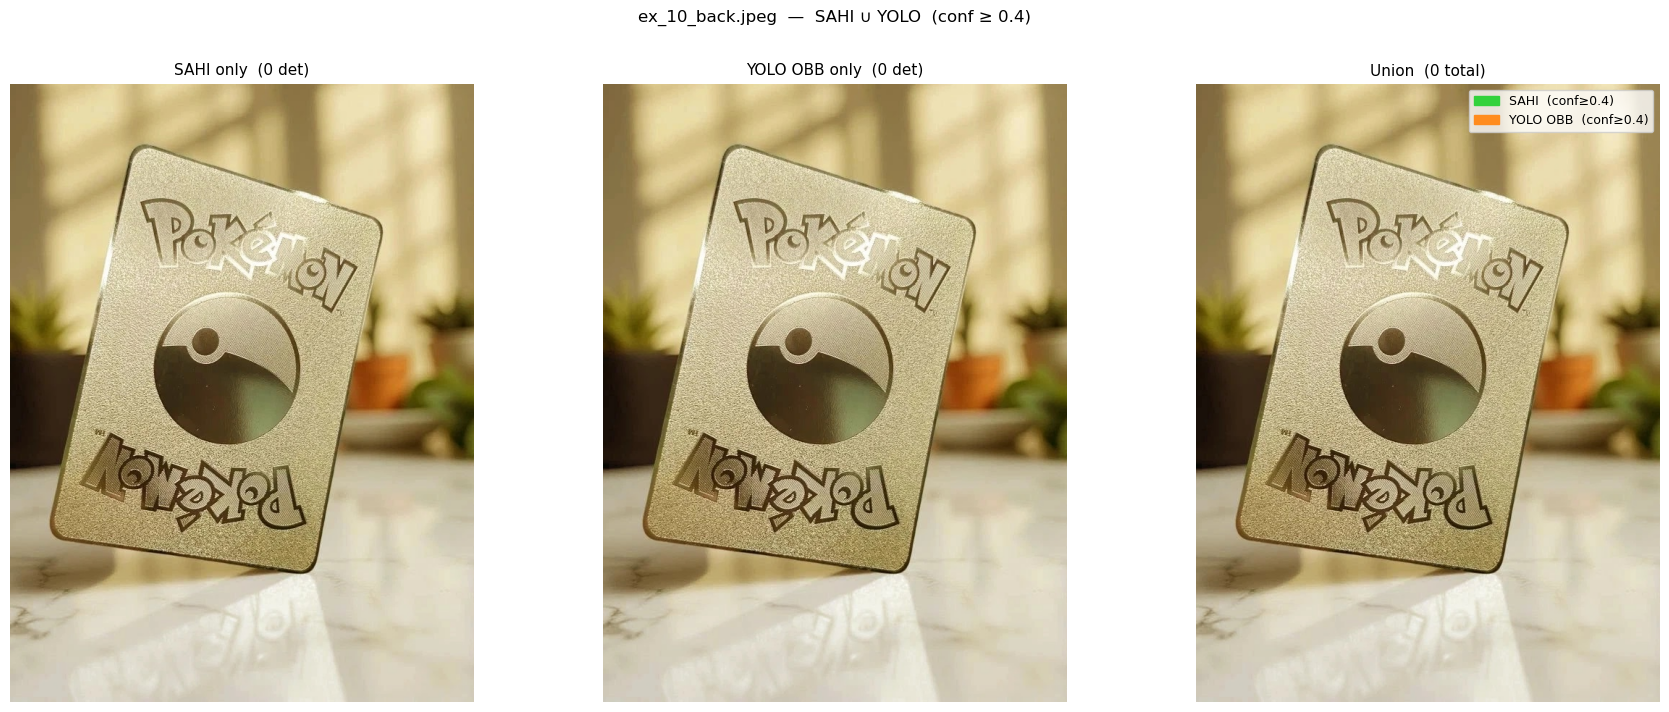

In [8]:
# ── SAHI ∪ YOLO: Union of high-confidence detections ──────────────────────────
# Runs SAHI (sliced inference) and direct YOLO independently, keeps only
# detections above UNION_CONF, then shows a 3-panel visual:
#   Left   - SAHI detections only  (axis-aligned bboxes, green)
#   Middle - YOLO OBB detections only (rotated quads, orange)
#   Right  - Union: both drawn together (no suppression between them)
#
# Useful for exploring which cards each method finds and misses.
# YOLO handles rotation; SAHI handles small/far cards — together they
# should cover both failure modes.

UNION_CONF       = 0.40   # minimum confidence to include a detection
UNION_IMAGE_PATH = TEST_IMAGES[3] if TEST_IMAGES else "to_label/abhi_0.jpeg"

img_bgr = cv2.imread(str(UNION_IMAGE_PATH))
assert img_bgr is not None, f"Cannot read: {UNION_IMAGE_PATH}"
h_u, w_u = img_bgr.shape[:2]

# ── 1. Direct YOLO OBB detections ─────────────────────────────────────────────
yolo_quads = []   # list of (pts (4,2), conf)
try:
    model  = _get_yolo()
    res    = model.predict(img_bgr, conf=UNION_CONF, verbose=False, imgsz=640)
    obb    = res[0].obb if res and res[0].obb is not None else None
    if obb is not None and len(obb):
        confs_y = obb.conf.cpu().numpy()
        pts_all = obb.xyxyxyxy.cpu().numpy()   # (N, 4, 2)
        for i in range(len(confs_y)):
            if float(confs_y[i]) >= UNION_CONF:
                yolo_quads.append((pts_all[i].astype(np.float32), float(confs_y[i])))
    print(f"YOLO  : {len(yolo_quads)} detection(s) above conf={UNION_CONF}")
except Exception as ex:
    print(f"YOLO  : error — {ex}")

# ── 2. SAHI detections ─────────────────────────────────────────────────────────
sahi_boxes = []   # list of (pts (4,2) axis-aligned corners, conf)
try:
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    import PIL.Image as PILImage

    _sahi_u = AutoDetectionModel.from_pretrained(
        model_type           = "ultralytics",
        model_path           = str(BEST_WEIGHTS),
        confidence_threshold = UNION_CONF,
        device               = "cpu",
    )
  
    img_pil = PILImage.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    #result  = get_sliced_prediction(
    #    img_pil, _sahi_u,
    #    slice_height=640, slice_width=640,
    #    overlap_height_ratio=0.25, overlap_width_ratio=0.25,
    #    verbose=0,
    #)
    
    result  = get_sliced_prediction(
        img_pil, _sahi_u,
        slice_height=200, slice_width=200,
        overlap_height_ratio=0.25, overlap_width_ratio=0.25,
        verbose=0,
    )


    
    preds = result.object_prediction_list

    try:
        import supervision as sv
        sv_dets = sv.Detections.from_sahi(result).with_nms()
        for i in range(len(sv_dets)):
            c = float(sv_dets.confidence[i])
            if c >= UNION_CONF:
                x1, y1, x2, y2 = sv_dets.xyxy[i]
                pts_s = np.array([[x1,y1],[x2,y1],[x2,y2],[x1,y2]], dtype=np.float32)
                sahi_boxes.append((pts_s, c))
    except Exception:
        for p in preds:
            c = p.score.value
            if c >= UNION_CONF:
                b = p.bbox
                pts_s = np.array([[b.minx,b.miny],[b.maxx,b.miny],
                                  [b.maxx,b.maxy],[b.minx,b.maxy]], dtype=np.float32)
                sahi_boxes.append((pts_s, c))

    print(f"SAHI  : {len(sahi_boxes)} detection(s) above conf={UNION_CONF}")
except ImportError:
    print("SAHI  : not installed (pip install sahi)")
except Exception as ex:
    print(f"SAHI  : error — {ex}")

print(f"Union : {len(yolo_quads) + len(sahi_boxes)} total (SAHI + YOLO, no suppression)")

# ── 3. Drawing helpers ─────────────────────────────────────────────────────────
_GREEN  = (50,  210,  60)    # SAHI boxes
_ORANGE = (30,  140, 255)    # YOLO OBB  (BGR: orange)
_FONT   = cv2.FONT_HERSHEY_SIMPLEX

def _draw_quad(canvas, pts, color, conf, thickness=2):
    "Draw a closed quadrilateral (4 corners) with a confidence label."
    pts_i = pts.reshape(4,2).astype(int)
    cv2.polylines(canvas, [pts_i], isClosed=True, color=color, thickness=thickness)
    lx, ly = int(pts_i[:,0].min()), int(pts_i[:,1].min())
    cv2.putText(canvas, f"{conf:.2f}", (lx, max(ly-5, 12)),
                _FONT, 0.6, color, 2, cv2.LINE_AA)

# ── 4. Build three panels ──────────────────────────────────────────────────────
panel_sahi  = img_bgr.copy()
panel_yolo  = img_bgr.copy()
panel_union = img_bgr.copy()

for pts_s, c in sahi_boxes:
    _draw_quad(panel_sahi,  pts_s, _GREEN, c, thickness=2)
    _draw_quad(panel_union, pts_s, _GREEN, c, thickness=2)

for pts_y, c in yolo_quads:
    _draw_quad(panel_yolo,  pts_y, _ORANGE, c, thickness=2)
    _draw_quad(panel_union, pts_y, _ORANGE, c, thickness=2)

# ── 5. Visualise ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
titles = [
    f"SAHI only  ({len(sahi_boxes)} det)",
    f"YOLO OBB only  ({len(yolo_quads)} det)",
    f"Union  ({len(sahi_boxes)+len(yolo_quads)} total)",
]
panels = [panel_sahi, panel_yolo, panel_union]

for ax, panel, title in zip(axes, panels, titles):
    ax.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11)
    ax.axis("off")

legend = [
    mpatches.Patch(color=(50/255, 210/255, 60/255),  label=f"SAHI  (conf≥{UNION_CONF})"),
    mpatches.Patch(color=(255/255, 140/255, 30/255), label=f"YOLO OBB  (conf≥{UNION_CONF})"),
]
axes[2].legend(handles=legend, loc="upper right", fontsize=9)

fig.suptitle(
    f"{Path(str(UNION_IMAGE_PATH)).name}  —  SAHI ∪ YOLO  (conf ≥ {UNION_CONF})",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

Tiles    : 4  (2 x 2, tile=640px, overlap=0.25)
Raw dets : 0
After NMS: 0


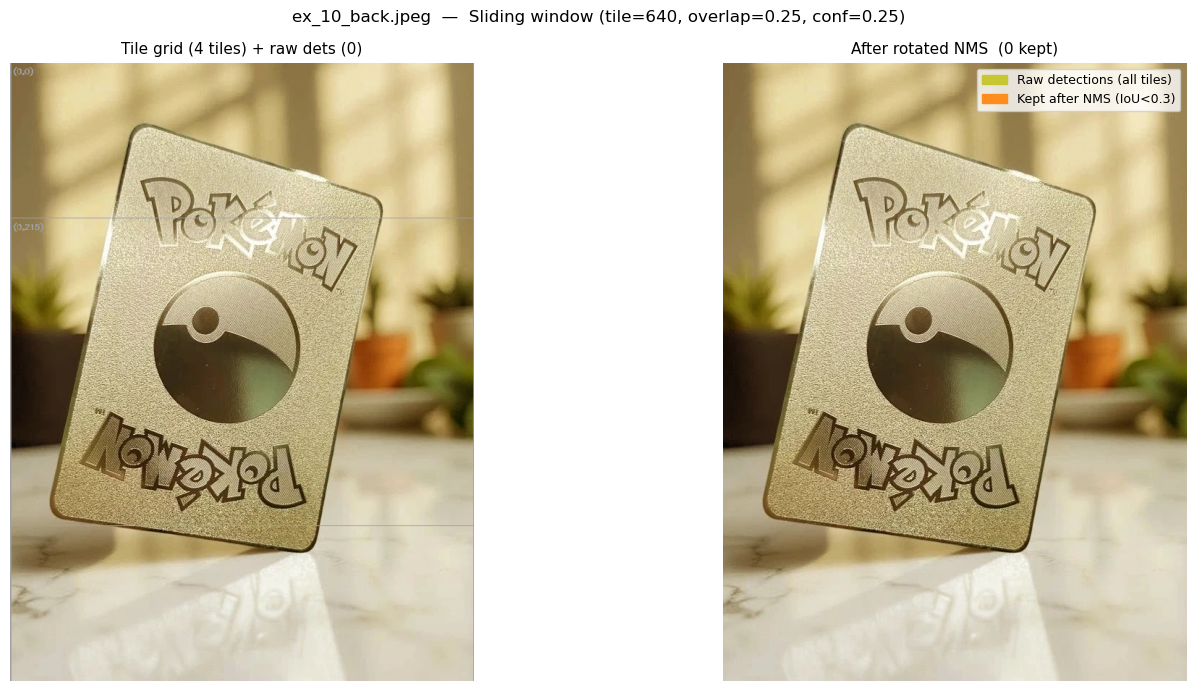

In [9]:
# ── Sliding Window: tile layout + detections visualiser ────────────────────────
# Shows every tile boundary, all raw OBB detections (faint), and the final
# kept detections after rotated NMS (bright), so you can see exactly which
# tiles fired and how NMS pruned duplicates.

SW_VIZ_IMAGE = TEST_IMAGES[3] if TEST_IMAGES else "to_label/abhi_0.jpeg"
SW_VIZ_CONF  = CONF_THRESHOLD   # lower this if no detections appear

img_sw = cv2.imread(str(SW_VIZ_IMAGE))
assert img_sw is not None, f"Cannot read: {SW_VIZ_IMAGE}"
h_sw, w_sw = img_sw.shape[:2]
step_sw = max(1, int(SW_TILE * (1 - SW_OVERLAP)))

def _sw_origins(size, tile, step):
    origs = list(range(0, size - tile, step)) if size > tile else []
    origs.append(max(0, size - tile))
    return sorted(set(origs))

xs_sw = _sw_origins(w_sw, SW_TILE, step_sw)
ys_sw = _sw_origins(h_sw, SW_TILE, step_sw)
n_tiles_sw = len(xs_sw) * len(ys_sw)

# ── Run YOLO on every tile, collect raw detections ────────────────────────────
model_sw = _get_yolo()
raw_pts_sw, raw_confs_sw, raw_tiles_sw = [], [], []

for y0 in ys_sw:
    for x0 in xs_sw:
        patch = img_sw[y0:y0+SW_TILE, x0:x0+SW_TILE]
        res   = model_sw.predict(patch, conf=SW_VIZ_CONF, verbose=False, imgsz=SW_TILE)
        obb   = res[0].obb if res and res[0].obb is not None else None
        if obb is None or len(obb) == 0:
            continue
        confs_p = obb.conf.cpu().numpy()
        pts_all = obb.xyxyxyxy.cpu().numpy()
        for i in range(len(confs_p)):
            pts = pts_all[i].copy().astype(np.float32)
            pts[:, 0] += x0
            pts[:, 1] += y0
            raw_pts_sw.append(pts)
            raw_confs_sw.append(float(confs_p[i]))
            raw_tiles_sw.append((x0, y0))

# ── Greedy rotated NMS ─────────────────────────────────────────────────────────
order_sw = sorted(range(len(raw_confs_sw)), key=lambda i: -raw_confs_sw[i])
kept_sw  = []
for i in order_sw:
    if all(_rotated_iou(raw_pts_sw[i], raw_pts_sw[j]) < SW_NMS_IOU for j in kept_sw):
        kept_sw.append(i)

print(f"Tiles    : {n_tiles_sw}  ({len(xs_sw)} x {len(ys_sw)}, "
      f"tile={SW_TILE}px, overlap={SW_OVERLAP})")
print(f"Raw dets : {len(raw_pts_sw)}")
print(f"After NMS: {len(kept_sw)}")
for rank, i in enumerate(kept_sw):
    x0t, y0t = raw_tiles_sw[i]
    print(f"  [{rank}] conf={raw_confs_sw[i]:.3f}  "
          f"from tile (x={x0t},y={y0t})  "
          f"mapped corners={raw_pts_sw[i].astype(int).tolist()}")

# ── Draw ───────────────────────────────────────────────────────────────────────
vis_tiles = img_sw.copy()
vis_dets  = img_sw.copy()

# Tile grid (light grey)
for y0 in ys_sw:
    for x0 in xs_sw:
        x2t = min(x0+SW_TILE, w_sw); y2t = min(y0+SW_TILE, h_sw)
        cv2.rectangle(vis_tiles, (x0, y0), (x2t, y2t), (160,160,160), 1)
        cv2.putText(vis_tiles, f"({x0},{y0})", (x0+4, y0+16),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (160,160,160), 1)

# Raw detections on tile vis (faint cyan)
for pts_r, c_r in zip(raw_pts_sw, raw_confs_sw):
    cv2.polylines(vis_tiles, [pts_r.reshape(4,1,2).astype(int)],
                  True, (200,200,50), 1)

# Raw detections (faint) on dets panel
for pts_r, c_r in zip(raw_pts_sw, raw_confs_sw):
    cv2.polylines(vis_dets, [pts_r.reshape(4,1,2).astype(int)],
                  True, (80,80,80), 1)

# Kept detections (bright orange) on both panels
_KEPT_COLOR = (30, 140, 255)
for rank, i in enumerate(kept_sw):
    pts_k = raw_pts_sw[i]
    for canvas in (vis_tiles, vis_dets):
        cv2.polylines(canvas, [pts_k.reshape(4,1,2).astype(int)],
                      True, _KEPT_COLOR, 2)
        lx = int(pts_k[:,0].min()); ly = int(pts_k[:,1].min())
        cv2.putText(canvas, f"#{rank} {raw_confs_sw[i]:.2f}",
                    (lx, max(ly-5,12)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, _KEPT_COLOR, 2, cv2.LINE_AA)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(vis_tiles, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Tile grid ({n_tiles_sw} tiles) + raw dets ({len(raw_pts_sw)})", fontsize=11)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(vis_dets, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"After rotated NMS  ({len(kept_sw)} kept)", fontsize=11)
axes[1].axis("off")

legend_sw = [
    mpatches.Patch(color=(0.78, 0.78, 0.20), label="Raw detections (all tiles)"),
    mpatches.Patch(color=(1.0,  0.55, 0.12), label=f"Kept after NMS (IoU<{SW_NMS_IOU})"),
]
axes[1].legend(handles=legend_sw, loc="upper right", fontsize=9)

fig.suptitle(
    f"{Path(str(SW_VIZ_IMAGE)).name}  —  Sliding window "
    f"(tile={SW_TILE}, overlap={SW_OVERLAP}, conf={SW_VIZ_CONF})",
    fontsize=12,
)
plt.tight_layout()
plt.show()